In [1]:
import sys
print(sys.executable)
sys.path.append('/home/nhewko/FEniCS/swelling/vf-swelling-fiber')
sys.path.append('/home/nhewko/FEniCS/swelling/vf-exputils')
sys.path.append('/home/nhewko/FEniCS/swelling/vf-fem')
sys.path.append('/home/nhewko/FEniCS/swelling/nonlinear-equation')
sys.path.append('/home/nhewko/FEniCS/vf-onset-sensitivity/src/libhopf')
sys.path.append('/home/nhewko/FEniCS/vf-onset-sensitivity/')
import libhopf

/home/nhewko/miniconda3/envs/fenics-env/bin/python


# Baseline Parameters Definition

In [2]:
import itertools
import os, sys
from pprint import pprint
from typing import Mapping, Any, List, Tuple, Union
from tqdm.notebook import tqdm

import numpy as np
import scipy.signal as signal
import dolfin as dfn
import ufl
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import tri
# pandas used for exporting values to csv
import pandas as pd
# re used for substrings (getting Escar from simulation name) 
import re

from femvf import forward, statefile as sf, meshutils
from femvf.models.transient import solid, fluid
from femvf.models.dynamical import (solid as dsolid, fluid as dfluid)
from femvf.postprocess import solid as slsig
from femvf import static
from femvf.load import load_transient_fsi_model, load_dynamical_fsi_model

from blockarray import blockvec

from vfsig import modal, fftutils, clinical

from exputils import h5utils, exputils, postprocutils
import scarV2

sys.path.append('../vf-onset-sensitivity')
import libhopf

dfn.set_log_level(50)

ExpParam = scarV2.ExpParam

## Default parameter values
# Change values here to reflect recently run simulations
# (can refer to output folder to obtain values) 
PARAMS_DEFAULT = ExpParam({
    'MeshName': 'BCS_M',
    'SD': 0.08,
    'DZ': 0.00, # Spacing in Z axis
    'NZ': 1, # Number of segments in Z direction
    'clscale': 0.25,
    'Ecov': 2.5e4, # Ecover (Pa)
    'Ebod': 5e4, # Ebody (Pa)
    'Escar': 1e5, # Escar (Pa)
    'vcov': 1, # Volume change of cover by swelling
    'mcov': 0, # Change in material properties due to swelling (?)
    'psub': 0.3e3 * 10, # Subglottal pressure (kPa)
    'dt': 10e-5, # Timestep size
    'tf': 1, # Simulation end time 
    'ModifyEffect': '',
    'SwellingDistribution':'uniform'
})

VCOVS = np.array([1.0])
MCOVS = np.array([0])
# ESCARS = np.array([5e3, 1e5, 2.5e4, 5e4, 1e5, 2.5e5, 5e5, 1e6])
ESCARS = np.array([1e5])
MESH_NAMES = ["BCS_M", "BCS_S", "BCS_I"]
SCAR_DIAS = np.array([0.04, 0.08, 0.12, 0.16])

# set output file location 
OUT_DIR = 'out'
POST_DIR = OUT_DIR

#set variables for saving images to svg
FIG_DIR = 'fig'
FIG_EXT = 'svg'

def iter_params(
    
        params: Mapping[str, Union[List[Any], Any]],
        default_params: ExpParam=PARAMS_DEFAULT
    ):
    """
    Return an iterator over `ExpParam` instances

    Parameters
    ----------
    params :
        A mapping from parameter labels to parameter value(s). Parameter
        instances are created for each parameter value given in the dictionary.
    defaults : ExpParam
        Default values for unspecified parameters
    """
    # Validate that all kwargs keys are valid parameters
    keys = list(params.keys())
    for key in keys:
        assert key in default_params

    # Make sure all parameter values are lists
    # This is so that you can iterate over them
    def _require_list(x):
        if isinstance(x, (list, tuple, np.ndarray)):
            return x
        else:
            return [x]

    _params = {
        key: _require_list(values)
        for key, values in params.items()
    }

    def _param(params):
        x = default_params.data.copy()
        x.update(params)
        return type(default_params)(x)

    for args in itertools.product(*list(_params.values())):
        yield (
            _param({key: val for key, val in zip(keys, args)})
        )

def load_measures(
        data: Mapping[str, Any],
        measure_name: str,
        params: Mapping[str, Union[List[Any], Any]],
        default_params: ExpParam=PARAMS_DEFAULT
    ):
    """
    Return measures for each supplied parameter(s)

    Parameters
    ----------
    data :
        A mapping from simuations ids/measure names to values
    measure_name : str
        A measure name to load
    params :
        A mapping from parameter labels to parameter value(s). Measurements
        are extracted from these parameters.
    defaults :
        Default values for unspecified parameters
    """
    keys = list(params.keys())
    vals = [
        data[f'{param.to_str()}/{measure_name}']
        for param in iter_params(params, default_params=default_params)
        
    ]
    if len(vals) == 1:
        return vals[0]
    else:
        return vals

def load_measures_np(
        data: Mapping[str, Any],
        measure_name: str,
        params: Mapping[str, Union[List[Any], Any]],
        default_params: ExpParam=PARAMS_DEFAULT
    ):
    """
    Return measures for each supplied parameter(s) (see `load_measures`)

    This functions returns outputs in a numpy array
    """
    return np.array(load_measures(data, measure_name, params, default_params))



## Load post-processed results

In [3]:
SIGNALS = {}

## Load simulation results, if error with case_names later, delete postprocess.h5 and run simulations again to clear "cached" simulations in POST_DIR folder
with h5py.File(f'{POST_DIR}/postprocess.h5', mode='r') as f:
    SIGNALS = h5utils.h5_to_dict(f, SIGNALS)
    

In [4]:
# Get a text summary of what cases were run and what measures were processed
from pprint import pprint
# case_names refer to each of the simulation names, the long file names in the "out" folder
case_names = [key.split('/')[0] for key in SIGNALS.keys()]
case_names = list(set(case_names))

# List of parameters that are saved in each simulation (mostly output parameters)
meas_names = [key.split('/')[1] for key in SIGNALS.keys()]
meas_names = list(set(meas_names))

## Loading Model Info

In [ ]:
# Generate empty arrays for mesh names and scar diameters in study, automatically populated to avoid having to recopy from python code
MeshNames = []
ScarDias = []

# Iterate through all the cases in the "out" folder (but not in subfolders)
for case_name in tqdm(case_names):
    # Check if the current mesh name (mesh type) is not in the list of cases
    if scarV2.ExpParam(case_name)['MeshName'] not in MeshNames:
        MeshNames.append(scarV2.ExpParam(case_name)['MeshName'])

    if scarV2.ExpParam(case_name)['SD'] not in ScarDias:
        ScarDias.append(scarV2.ExpParam(case_name)['SD'])

# Sort SD array from smallest to largest to be proper and avoid issues with plotting
data_sorted = np.stack((ScarDias), axis=0)
np_ScarDias = data_sorted[data_sorted.argsort()][::1]
# Copy sorted numpy SD array to the regular SD array, required for searching
for itr in range(0, len(ScarDias), 1):
    ScarDias[itr] = float(np_ScarDias[itr])

MODEL = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
XREF = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
SDOF_TO_VERT = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
VERT_TO_VDOF = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
VERT_TO_SDOF = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
MESH = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
CELLS = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
dofs_med = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
VERT_MED = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
mf_cell = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
mv_cell = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
cells_cover = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
verts_cover = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
verts_body = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
verts_interface = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
_xy = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
idx_interface = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
VERT_INT = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
V_CG1 = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
DOFMAP_CG1 = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
V_DG0 = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
DOFMAP_DG0 = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]


# iM = index_Mesh, iS = index_Scar
for iM in range(0, len(MeshNames)):
    for iS in range(0, len(ScarDias)):
        # Substituting default meshname and scardia values with the currently iterated ones
        MODEL[iM][iS] = scarV2.setup_model(PARAMS_DEFAULT.substitute({
            # Obtaining value from index of each property to avoid using "MeshNames.index(iM)" for every index call
            'MeshName': MeshNames[iM],
            'SD': ScarDias[iS]
        }))

        # Load these mesh related constants for plotting configurations
        XREF[iM][iS] = MODEL[iM][iS].solid.XREF
        SDOF_TO_VERT[iM][iS] = dfn.dof_to_vertex_map(MODEL[iM][iS].solid.residual.form['coeff.fsi.p1'].function_space())
        VERT_TO_VDOF[iM][iS] = dfn.vertex_to_dof_map(MODEL[iM][iS].solid.residual.form['coeff.state.u1'].function_space())
        VERT_TO_SDOF[iM][iS] = dfn.vertex_to_dof_map(MODEL[iM][iS].solid.residual.form['coeff.fsi.p1'].function_space())
        MESH[iM][iS] = MODEL[iM][iS].solid.residual.mesh()
        CELLS[iM][iS] = MESH[iM][iS].cells()
        
        dofs_med[iM][iS] = np.concatenate([fsimap.dofs_solid for fsimap in MODEL[iM][iS].fsimaps])
        VERT_MED[iM][iS] = SDOF_TO_VERT[iM][iS][MODEL[iM][iS].fsimaps[0].dofs_solid]
        
        ## Get all vertices on the body-cover interface
        mf_cell[iM][iS] = MODEL[iM][iS].solid.residual.mesh_function('cell')
        mv_cell[iM][iS] = MODEL[iM][iS].solid.residual.mesh_function_label_to_value('cell')
        
        if 'inferior' in mv_cell[iM][iS]:
            cells_cover[iM][iS] = np.concatenate([
                mf_cell[iM][iS].where_equal(mv_cell[iM][iS]['inferior']),
                mf_cell[iM][iS].where_equal(mv_cell[iM][iS]['medial']),
                mf_cell[iM][iS].where_equal(mv_cell[iM][iS]['superior'])
            ])
        elif 'cover' in mv_cell[iM][iS]:
            cells_cover[iM][iS] = mf_cell[iM][iS].where_equal(mv_cell[iM][iS]['cover'])
        else:
            assert False
        
        verts_cover[iM][iS] = CELLS[iM][iS][cells_cover[iM][iS]].reshape(-1)
        verts_body[iM][iS] = CELLS[iM][iS][mf_cell[iM][iS].where_equal(mv_cell[iM][iS]['body'])].reshape(-1)
        verts_interface[iM][iS] = np.array(list(set(verts_cover[iM][iS]).intersection(set(verts_body[iM][iS]))))
        
        _xy[iM][iS] = MESH[iM][iS].coordinates()[verts_interface[iM][iS]]
        idx_interface[iM][iS] = meshutils.sort_vertices_by_nearest_neighbours(_xy[iM][iS])
        VERT_INT[iM][iS] = verts_interface[iM][iS][idx_interface[iM][iS]]
        
        V_CG1[iM][iS] = dfn.FunctionSpace(MESH[iM][iS], 'CG', 1)
        DOFMAP_CG1[iM][iS] = V_CG1[iM][iS].dofmap()
        V_DG0[iM][iS] = dfn.FunctionSpace(MESH[iM][iS], 'DG', 0)
        DOFMAP_DG0[iM][iS] = V_DG0[iM][iS].dofmap()

  0%|          | 0/12 [00:00<?, ?it/s]

/home/nhewko/FEniCS/swelling/vf-fem/femvf/meshutils.py:96: UserWarning: Loading 'gmsh' mesh from existing '.xdmf' files.
  warnings.warn(


Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.


In [6]:
import scipy.signal as signal
def normal(x):
    """
    Return the normal vector to a 2D curve `x`
    """
    assert x.ndim == 2
    assert x.shape[-1] == 2

    dx = np.zeros(x.shape)
    dx[1:, :] = x[1:] - x[:-1]
    s = np.cumsum(np.linalg.norm(dx, axis=-1))

    # Tangent
    dx = np.gradient(x[:, 0], s, axis=0)
    dy = np.gradient(x[:, 1], s, axis=0)

    # Non-unit normal
    nx = dy
    ny = -dx
    n = np.stack([nx, ny], axis=-1)
    return n/np.linalg.norm(n, axis=-1, keepdims=True)

def offset_normal(x, n):
    return x + n

def tavg(y, t, axis=-1):
    """
    Return the time average of a signal
    """
    # tavg_y = np.trapz(y, x=t, axis=axis)/np.trapz(np.ones(t.shape), x=t, axis=axis)
    tavg_y = np.trapezoid(y, x=t, axis=axis)/np.trapezoid(np.ones(t.shape), x=t, axis=axis)
    return tavg_y

def make_solve_static(model):
    """
    Return the static state for a solid model with no external loading
    """
    forms = model.solid.forms
    f1uva = forms['form.un.f1uva']
    u1 = forms['coeff.state.u1']
    bc_dir = forms['bc.dirichlet']

    def solve_static():
        dfn.solve(f1uva==0, u1, bcs=[bc_dir])
        x = model.state1.copy()
        x['v'][:] = 0
        x['a'][:] = 0
        return x
    return solve_static

## Setup function to compute SPL from t/q

def proc_prms(t, q):
    """
    Return the RMS radiated pressure at 1m using a piston-in-baffle approximation
    """
    dt = t[1]-t[0]

    # Assume a 2cm vocal fold length
    # This is needed to get a true flow rate since the 1D model flow rate
    # is over one dimension
    piston_params = {
        'r': 100.0,
        'theta': 0.0,
        'a': 1.0,
        'rho': 0.001225,
        'c': 343*100
    }
    VF_LENGTH = 2
    win = signal.windows.tukey(q.size, alpha=0.15)
    wq = win*q*VF_LENGTH
    fwq = np.fft.rfft(wq)
    freq = np.fft.rfftfreq(wq.size, d=dt)

    fwp = clinical.prad_piston(fwq, f=freq*2*np.pi, piston_params=piston_params)

    # This computes the squared sound pressure
    psqr = fftutils.power_from_rfft(fwp, fwp, n=fwq.size)

    # The rms pressure in units of Pa
    prms = np.sqrt(psqr/fwp.size)

    return prms

def get_dx(model, name=None):
    cell_label_to_id = model.solid.residual.mesh_function_label_to_value('cell')
    _dx = model.solid.residual.measure('dx')
    if name is None:
        dx = _dx
    elif name == 'cover':
        # dx = (
        #     _dx(int(cell_label_to_id['inferior']))
        #     +_dx(int(cell_label_to_id['medial']))
        #     + _dx(int(cell_label_to_id['superior']))
        # )
        dx = _dx(int(cell_label_to_id['cover']))
    elif name == 'scar':
        dx = _dx(int(cell_label_to_id['scar']))
    else:
        dx = _dx(int(cell_label_to_id[name]))
    return dx

# Figures
## Figure constants

Converts the output figure names to a manuscript ordered names (Fig1, Fig2, ...)

In [7]:
fig_names = [
    'SwelledGeometryVsV',
    'CoverMassVsV',
    'F0VsV',
    'ContactVMCycleDynamicsVsV',
    'StressFieldvsV',
    'AvgVMStressVsV'
]

## Set any figure constants
FIG_TYPE = 'manuscript'
# FIG_TYPE = 'presentation'

CM = 1/2.54
if FIG_TYPE == 'manuscript':
    FIG_DIR = 'fig/manuscript'
    FIG_EXT = 'pdf'

    FIG_LX = 8.4*CM
    FIG_LX_WIDE = 17.4*CM

    FIG_LY = 23.4*CM
    FONTSIZE = 9
elif FIG_TYPE == 'presentation':
    FIG_DIR = 'fig/presentation'
    FIG_EXT = 'svg'

    FIG_LX = 7.5*CM
    FIG_LX_WIDE = 30*CM

    FIG_LY = 13*CM
    FONTSIZE = 12

SIZE_SMALL = (FIG_LX, FIG_LX)
SIZE_MED = (FIG_LX, 1.25*FIG_LX)
SIZE_MED_WIDE = (FIG_LX_WIDE, 1.25*FIG_LX)
SIZE_LARGE = (FIG_LX, 1.5*FIG_LX)
SIZE_LARGE_WIDE = (FIG_LX_WIDE, 1.5*FIG_LX)

DPI = 250

# Colors
COLOR_CYCLE = plt.rcParams['axes.prop_cycle'].by_key()['color']
MARKER_CYCLE = ['.', '*', 'x', 'o']
LS_CYCLE = ['-', '-.', ':', '--', (0, (1, 4))]

mpl.rcParams.update({
    'figure.dpi': 200,
    'font.size': FONTSIZE,
    'text.usetex': False,
    'legend.handlelength': 2,
    'text.latex.preamble': (
        r'\usepackage{amsmath}'
        r'\usepackage{siunitx}'
        r'\usepackage{sansmath}'
        r'\sansmath'
        r'\sisetup{detect-all}'
        r'\newcommand{\avg}[1]{\underset{#1}{\mathrm{avg}} \, }'
    )
})
# mpl.rcParams['']

## Functions for plotting percent change
def per_change_forward(y, y0):
    return (y-y0)/y0 * 100

def per_change_inv(y, y0):
    return y*y0/100 + y0

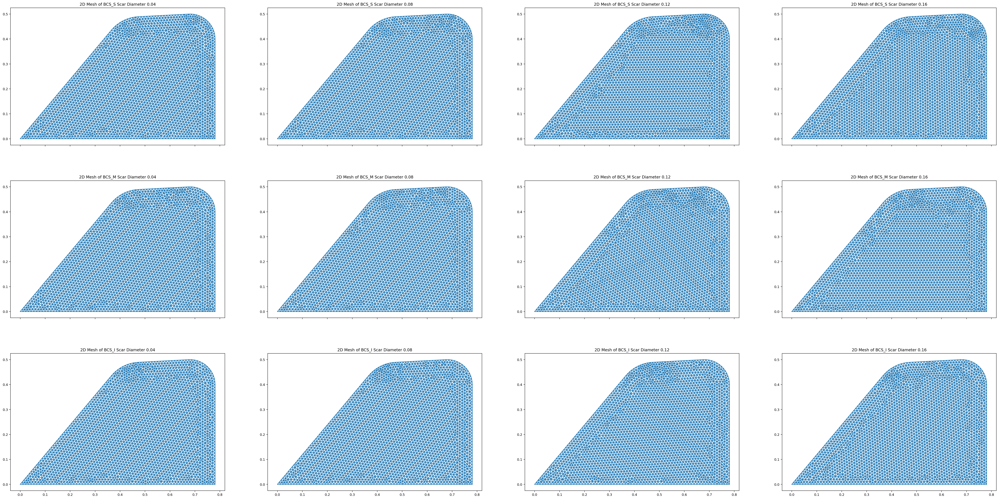

In [8]:
from femvf.meshutils import extract_zplane_facets
facets = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
facets_idx = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]

# Create grid of subplots to display meshes (at least for testing purposes)
fig, axs = plt.subplots(len(MeshNames), len(ScarDias), sharex=True, sharey=False, figsize=(48, 24))

# iM = index_Mesh, iS = index_Scar
for iM in range(0, len(MeshNames)):
    for iS in range(0, len(ScarDias)):
        # Get mesh from model
        facets[iM][iS] = extract_zplane_facets(MESH[iM][iS], 1.5/10)
        facets_idx[iM][iS] = [facet.index() for facet in facets[iM][iS]]

        from matplotlib.tri import Triangulation
        
        # Extract full triangle data
        cells = MESH[iM][iS].cells()
        coords = MESH[iM][iS].coordinates()

        # TODO Would be nice to have scar region coloured differently
        axs[iM, iS].triplot(coords[:, 0], coords[:, 1], triangles=cells)
        axs[iM, iS].set_aspect('equal')
        axs[iM, iS].set_title("2D Mesh of " + MeshNames[iM] + " Scar Diameter " + str(ScarDias[iS]))


  0%|          | 0/12 [00:00<?, ?it/s]

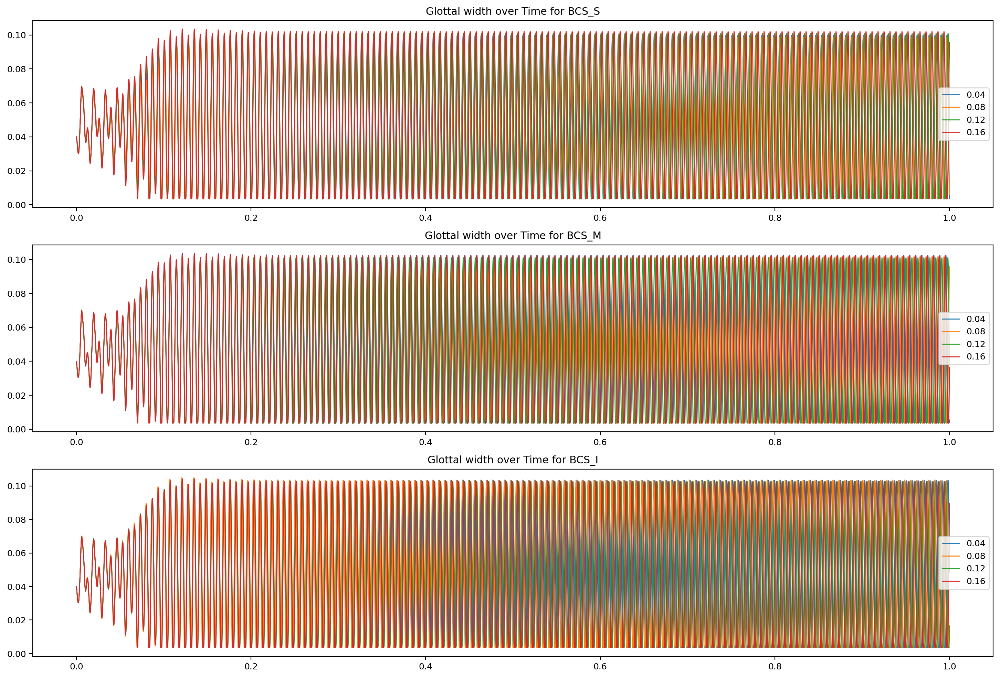

In [10]:
# Scar locations are on different plots, but scar diameters plotted together for comparison 
fig, axs = plt.subplots(len(MeshNames), 1, sharex=False, sharey=False, figsize=(18, 12))

for case_name in tqdm(case_names):
    t = SIGNALS[case_name+'/time.t']
    gw = SIGNALS[case_name+'/time.gw']

    # get mesh name and scar diameter from case_name
    mesh_name = scarV2.ExpParam(case_name)['MeshName']
    scar_dia = scarV2.ExpParam(case_name)['SD']

    # Create subplots for each scar location
    axs[MeshNames.index(mesh_name)].set_title('Glottal width over Time for ' + mesh_name)
    axs[MeshNames.index(mesh_name)].plot(t, gw, linewidth=1, linestyle="-")
    
    # TODO Plotted ScarDias are likely out of order since case_names is not in order
    axs[MeshNames.index(mesh_name)].legend(ScarDias, loc='right')
    
    # can also process baseline sims from here by referring to out/baseline/postprocess.h5
    # Export time and y values to csv file for easier comparison elsewhere
    df = pd.DataFrame({"glottal_gap" : gw, "time" : t})
    # df.to_csv(FIG_DIR + "/"+ str(f"{escar:.2e}") + "_glottal_gap.csv", index=False)


### Additional post-processing

In [11]:
## Post-process stress fields at fixed points
from femvf import static
from femvf.postprocess.solid import StressVonMisesField, StressHydrostaticField

for case_name in tqdm(case_names):
    # Load the corresponding parameters and appropriate model
    params = scarV2.ExpParam(case_name)
    model = scarV2.setup_model(params)

    svm_field = StressVonMisesField(model)
    shydro_field = StressHydrostaticField(model)

    _, controls, prop = scarV2.setup_state_control_props( params,model)
    control = controls[0]
    model.set_prop(prop)
    model.dt = 1e6

    state_fp = scarV2.setup_ini_state(params, model)
    # state_uqp_fp, info = static.static_coupled_configuration_picard(model, control, prop)
    # # pprint(info)
    # state_fp = model.state1.copy()
    # state_fp[:] = 0.0
    # state_fp[['u', 'q', 'p']] = state_uqp_fp[['u', 'q', 'p']]
    svm = svm_field(state_fp, control, prop)
    shydro = shydro_field(state_fp, control, prop)

    # Save the fixed-point von Mises/hydrostatic stresses
    SIGNALS[f'{case_name}/field_fp_vm'] = svm
    SIGNALS[f'{case_name}/field_fp_hydrostatic'] = shydro

  0%|          | 0/12 [00:00<?, ?it/s]

Expecting bilinear form.
Expecting bilinear form.


/home/nhewko/FEniCS/swelling/vf-fem/femvf/meshutils.py:96: UserWarning: Loading 'gmsh' mesh from existing '.xdmf' files.
  warnings.warn(


Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.


/home/nhewko/FEniCS/swelling/vf-fem/femvf/meshutils.py:96: UserWarning: Loading 'gmsh' mesh from existing '.xdmf' files.
  warnings.warn(


...

/home/nhewko/FEniCS/swelling/vf-fem/femvf/meshutils.py:96: UserWarning: Loading 'gmsh' mesh from existing '.xdmf' files.
  warnings.warn(


Expecting bilinear form.
Expecting bilinear form.


/home/nhewko/FEniCS/swelling/vf-fem/femvf/meshutils.py:96: UserWarning: Loading 'gmsh' mesh from existing '.xdmf' files.
  warnings.warn(


Expecting bilinear form.
Expecting bilinear form.


/home/nhewko/FEniCS/swelling/vf-fem/femvf/meshutils.py:96: UserWarning: Loading 'gmsh' mesh from existing '.xdmf' files.
  warnings.warn(


In [29]:
import ufl
_sig_update = {}

# Define arrays that are used for plotting results
F0_array = np.empty((len(MeshNames), len(ScarDias)), dtype='float64')
amp_array = np.empty((len(MeshNames), len(ScarDias)), dtype='float64')
SPL_array = np.empty((len(MeshNames), len(ScarDias)), dtype='float64')
OQ_array = np.empty((len(MeshNames), len(ScarDias)), dtype='float64')
# tolerance for determining if glottis is closed (needed due to rounding errors and contact width)
GWRange = 1.5

#from libhopf import signal
for case_name in tqdm(case_names):
    params = scarV2.ExpParam(case_name)
    model = scarV2.setup_model(params)

    #find indices of the current study since both case and SD are out of order in case_name 
    curr_mesh = MeshNames.index(scarV2.ExpParam(case_name)['MeshName'])
    curr_scar = ScarDias.index(scarV2.ExpParam(case_name)['SD'])

    dx = get_dx(model)
    dx_cover = get_dx(model, 'cover')
    _f = dfn.Function(model.solid.residual.form['coeff.prop.emod'].function_space())
    # dofs_cover = meshutils.

    ## Add region averaged measures of stress fields
    stress_field_keys = {'field_tini_vm', 'field_tavg_vm', 'field_fp_vm'}
    for stress_field_key in stress_field_keys:
        key = f'{case_name}/{stress_field_key}'
        if key in SIGNALS:
            # print(SIGNALS[key].shape)
            try:
                _f.vector()[:] = SIGNALS[key]
                cover_vol = dfn.assemble(1*dx_cover)
                _sig_update[f'{case_name}/cover_avg_{stress_field_key}'] = dfn.assemble(_f*dx_cover)/cover_vol
            except:
                pass

    # Likely not needed because swelling-related, but keeping commented out just in case
    ## Add time/space averaged viscous dissipation rate
    # t = SIGNALS[f'{case_name}/time.t']
    # N = t.size
    # wvisc_stats = SIGNALS[f'{case_name}/time.spatial_stats_viscous']
    # _sig_update[f'{case_name}/avg_wvisc'] = tavg(wvisc_stats['avg'][-N//2:], t[-N//2:])

    ## Add cover mass and volume - Not Needed
    # state_swollen = scarV2.setup_ini_state(params, model)
    # model.set_fin_state(state_swollen)

    # dens = model.solid.residual.form['coeff.prop.rho']
    # disp = model.solid.residual.form['coeff.state.u1']
    # def_grad = ufl.grad(disp)
    # j = ufl.det(def_grad + dfn.Identity(2))
    # _sig_update[f'{case_name}/mass_cover'] = dfn.assemble(dens*dx_cover)
    # _sig_update[f'{case_name}/mass_total'] = dfn.assemble(dens*dx)
    # _sig_update[f'{case_name}/vol_cover'] = dfn.assemble(j*dx_cover)
    # _sig_update[f'{case_name}/vol_total'] = dfn.assemble(j*dx)

    ## Add Fo
    t = SIGNALS[f'{case_name}/time.t']
    gw = SIGNALS[f'{case_name}/time.gw']
    N = gw.size//2
    gw = gw[-N:]
    dt = t[1]-t[0]

    fund_freq, fund_phase, dfreq, dphase, info = modal.fundamental_mode_from_peaks(gw, dt, height=np.max(gw)*0.8)
    # print(fund_freq)
    _sig_update[f'{case_name}/fund_freq'] = fund_freq
    _sig_update[f'{case_name}/dfreq'] = dfreq
    _sig_update[f'{case_name}/period_sample'] = 1/(fund_freq *dt)

    F0_array[curr_mesh][curr_scar] = fund_freq

    # These fundamental frequencies are broken, keep returning the same value across all cases
    # fund_freq, fund_phase, dfreq, dphase, info = modal.fundamental_mode_from_rfft(gw, t[1]-t[0])
    # _sig_update[f'{case_name}/fund_freq_dft'] = fund_freq
    # _sig_update[f'{case_name}/dfreq_dft'] = dfreq


    
    ## Add SPL
    t = SIGNALS[f'{case_name}/time.t']
    q = SIGNALS[f'{case_name}/time.q']

    # Divide `prms` by 10 to get units of [Pa]
    prms = proc_prms(t, q)/10
    _sig_update[f'{case_name}/prms'] = prms
    _sig_update[f'{case_name}/spl'] = 20*np.log10(prms/20e-6)
    SPL_array[curr_mesh][curr_scar] = _sig_update[f'{case_name}/spl']
    
    ## Add vibration amplitude
    # assert gw.ndim == 1
    _sig_update[f'{case_name}/amplitude'] = gw.max()-gw.min()
    amp_array[curr_mesh][curr_scar] = _sig_update[f'{case_name}/amplitude']

    # Von Mises is array of fixed points, need different way to get
    # vm_array[itr] = SIGNALS[f'{case_name}/field_fp_vm']

    # OQ is never truely 0 due to min glottal width required for Bernoulli eq
    # Due to rounding errors and contact force, a range of values is used with respect to the found minimum gw
    # Samples the second half of the simulation data
    gw = SIGNALS[f'{case_name}/time.gw']
    sustained_gw = gw[round(0.5*len(gw)): len(gw)]

    for curr_gw in sustained_gw:
        if curr_gw <= GWRange*gw.min():
            OQ_array[curr_mesh][curr_scar]+=1
    OQ_array[curr_mesh][curr_scar] = 1-(OQ_array[curr_mesh][curr_scar]/len(sustained_gw))

    # spatial_stats_vm, field.tavg_vm, max area declination rate (max negative slope)
    # Von Mises contact stress
    
SIGNALS.update(_sig_update)

  0%|          | 0/12 [00:00<?, ?it/s]

Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.
Expecting bilinear form.


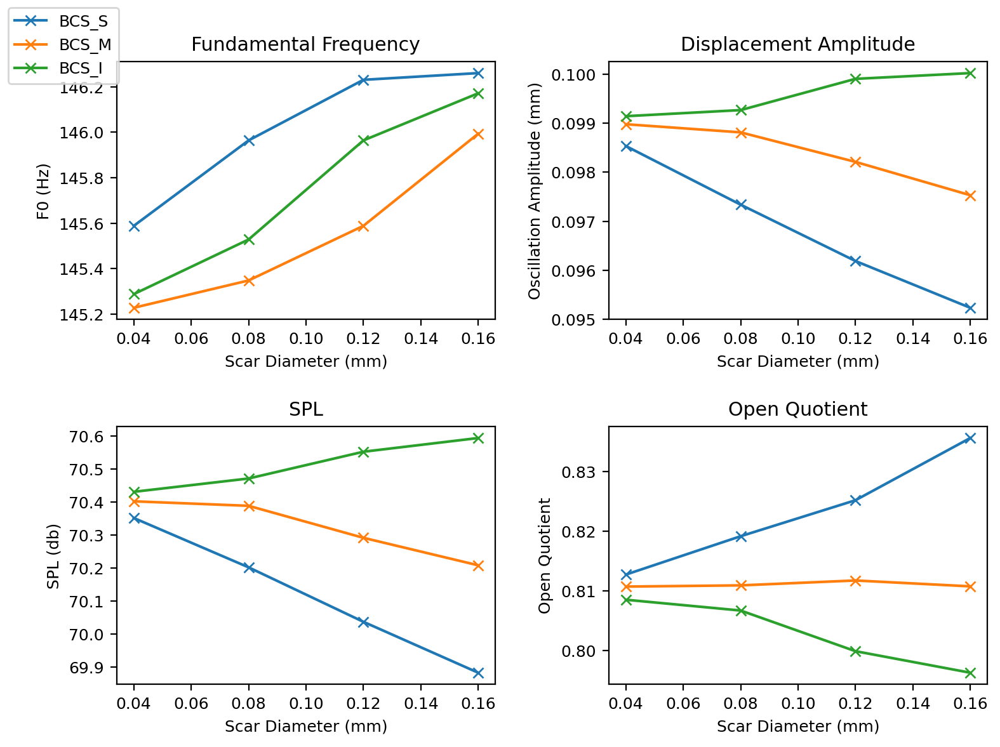

In [30]:
## Plot F0, Amplitude, SPL and OQ for all cases
fig, axs = plt.subplots(2, 2, sharex=False, sharey=False, figsize=(8, 6))
for iM in MeshNames:
    # # Create total plot, dimensions are length, width
    axs[0, 0].set_title('Fundamental Frequency')
    axs[0, 0].set_xlabel("Scar Diameter (mm)")
    axs[0, 0].set_ylabel("F0 (Hz)")
    # axs[0, 0].axis([0.03, 0.17, 145.999, 146.001])
    axs[0, 0].plot(ScarDias, F0_array[MeshNames.index(iM),:], marker="x")
        
    axs[0, 1].set_title("Displacement Amplitude")
    axs[0, 1].set_xlabel("Scar Diameter (mm)")
    axs[0, 1].set_ylabel("Oscillation Amplitude (mm)")
    axs[0, 1].plot(ScarDias, amp_array[MeshNames.index(iM),:], marker="x")
    
    axs[1, 0].set_title("SPL")
    axs[1, 0].set_xlabel("Scar Diameter (mm)")
    axs[1, 0].set_ylabel("SPL (db)")
    axs[1, 0].plot(ScarDias, SPL_array[MeshNames.index(iM),:], marker="x")

    axs[1, 1].set_title("Open Quotient")
    axs[1, 1].set_xlabel("Scar Diameter (mm)")
    axs[1, 1].set_ylabel("Open Quotient")
    axs[1, 1].plot(ScarDias, OQ_array[MeshNames.index(iM),:], marker="x")

fig.legend(MeshNames, loc='upper left')
fig.tight_layout(pad=2)

## Contact Stresses

In [15]:
residual = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
mesh = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
facet_function = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
facet_data = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]
dofmap = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]

# Coordinates of all facets along the surface, which is needed for the 2D plot
facet_coords = [[[] for i in range(len(ScarDias))] for j in range(len(MeshNames))]
facet_cell_neighbour_dofs = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]

# Surface nodes normalized to s space
facet_s = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]

# Contact quotient
dat_cq = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]

# Contact pressure field
dat = [[0 for i in range(len(ScarDias))] for j in range(len(MeshNames))]

# iM = index_Mesh, iS = index_Scar
for iM in range(0, len(MeshNames)):
    for iS in range(0, len(ScarDias)):
        ## Compute the 's' coordinate for the DG0 contact pressure
        residual[iM][iS] = MODEL[iM][iS].solid.residual
        mesh[iM][iS] = residual[iM][iS].mesh()

        # facets are 1d elements, not the same as nodes. Will need some other method to link the nodes and facets together
        # https://olddocs.fenicsproject.org/dolfin/2016.1.0/python/programmers-reference/cpp/mesh/Vertex.html
        # https://olddocs.fenicsproject.org/dolfin/2016.1.0/python/programmers-reference/cpp/mesh/Facet.html
        
        facet_function[iM][iS] = residual[iM][iS].mesh_function('facet')
        facet_data[iM][iS] = residual[iM][iS].mesh_function_label_to_value('facet')
        dofmap[iM][iS] = residual[iM][iS].form['coeff.prop.eta'].function_space().dofmap()

        # Find facets along the traction surface and associated DG0 dofs
        facet_cell_neighbour_idxs = []
        for facet in dfn.facets(mesh[iM][iS]):
        # get all facet ids and check if it is along the pressure surface
            facet_idx = facet.index()
            if facet_function[iM][iS][facet_idx] == facet_data[iM][iS]['pressure']:
                facet_coord = facet.midpoint().array()[:2]
                # Save the new surface coords and id to separate numpy lists (keep separate for sorting soon)
                facet_coords[iM][iS].append(facet_coord)
                
                cell_neighbour_idx = facet.entities(2)
                assert len(cell_neighbour_idx) == 1
                cell_neighbour_idx = cell_neighbour_idx[0]
                facet_cell_neighbour_idxs.append(cell_neighbour_idx)

        facet_coords[iM][iS] = np.array(facet_coords[iM][iS])
        facet_cell_neighbour_idxs = np.array(facet_cell_neighbour_idxs)
        facet_cell_neighbour_dofs[iM][iS] = np.array(dofmap[iM][iS].entity_dofs(mesh[iM][iS], 2, facet_cell_neighbour_idxs))
        
        # Sort the DG0 dofs in streamwise increasing order
        from femvf.meshutils import sort_vertices_by_nearest_neighbours
        
        idx_sort = sort_vertices_by_nearest_neighbours(facet_coords[iM][iS], np.array([0,0]))
        facet_coords[iM][iS] = facet_coords[iM][iS][idx_sort]
        
        facet_cell_neighbour_dofs[iM][iS] = facet_cell_neighbour_dofs[iM][iS][idx_sort]
        _facet_coords = np.concatenate([facet_coords[iM][iS], np.array([[0, 0]])], axis=0)
        ds = np.linalg.norm(_facet_coords[1:]-_facet_coords[:-1], axis=-1)

        # Surface facets converted to a range from -1 to 1, with 0 being the separation point(?)
        facet_s[iM][iS] = np.cumsum(ds) - 1

        _dat_pcfield = load_measures_np(SIGNALS, 'field.tavg_pc', {'MeshName': MeshNames[iM], 'SD': ScarDias[iS]})
        _dat_pc = load_measures_np(SIGNALS, 'time.spatial_stats_con_p', {'MeshName': MeshNames[iM], 'SD': ScarDias[iS]})
        _dat_pa = load_measures_np(SIGNALS, 'time.spatial_stats_con_a', {'MeshName': MeshNames[iM], 'SD': ScarDias[iS]})

        # Obtain contact quotient (amount of time with contact, defined by where the contact pressure is non-zero)
        # This also accounts for the initial transient state, but is assumed to be negligible with sufficiently long simulation time
        dat_cq[iM][iS] = len(_dat_pa.nonzero())/len(_dat_pa)
        
        # Load the contact pressure field and account for averaging over contact times only
        # Convert the unit to kpa
        # If multiplying by `1/cq`, the contact pressure is averaged over contact only
        dat[iM][iS] = _dat_pcfield/10/1e3 * 1/dat_cq[iM][iS]

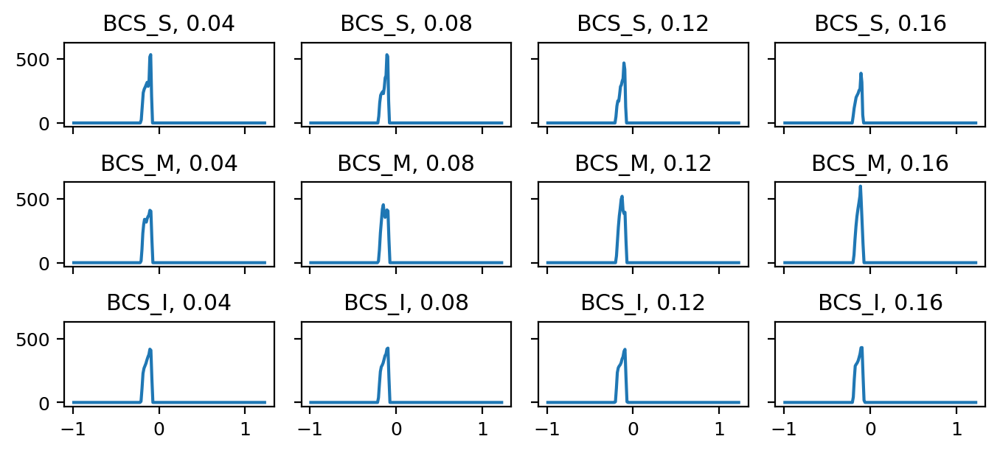

In [17]:
## Plot contact surface pressure profiles (line plot over 's' coordinate)
if FIG_TYPE == 'manuscript':
    fig, axs = plt.subplots(len(MESH_NAMES), len(SCAR_DIAS), figsize=(FIG_LX_WIDE, 8*CM), sharex=True, sharey=True)
elif FIG_TYPE == 'presentation':
    fig, axs = plt.subplots(len(MESH_NAMES), len(SCAR_DIAS), figsize=(FIG_LX_WIDE, FIG_LY), sharex=True, sharey=True)

# iM = index_Mesh, iS = index_Scar
for iM in range(0, len(MeshNames)):
    for iS in range(0, len(ScarDias)):

        pc_medial = dat[iM][iS][facet_cell_neighbour_dofs[iM][iS]]
        axs[iM][iS].plot(facet_s[iM][iS], pc_medial)
        axs[iM, iS].set_title(MeshNames[iM] + ", " + str(ScarDias[iS]))
        
        # Add annotation for increasing scar diameter
        # gs_ann = mpl.gridspec.GridSpec(len(MESH_NAMES), len(SCAR_DIAS), figure=fig)
        # ax_ann = fig.add_subplot(gs_ann[0, :])
        # ax_ann.axis('off')
        # ax_ann.annotate(
        #     "increasing scar diameter", ha='right', va='center',
        #     xytext=(0.4, 1.3), xy=(.6, 1.3), xycoords=ax_ann.transAxes,
        #     arrowprops={'arrowstyle':'simple', 'fc': 'black'}
        # )
        
        # for ax, mesh_name in zip(axs, MESH_NAMES):
        #     ax.set_xlim(0.6, 1.0)
        #     ax.set_xlabel("$s$ [cm]")
        #     ax.set_title(mesh_name)
        fig.tight_layout()
        # fig.savefig(f'{FIG_DIR}/ContactPressureFieldVsMesh.{FIG_EXT}')




# for ax, mcov in zip(axs, mcovs):
#     for vcov, pc, cq, marker in zip(vcovs, dat[mcov], dat_cq[mcov], MARKER_CYCLE):
#         kwargs_line = {'marker': marker, 'markevery': 5, 'ms': 5}
#         pc_medial = pc[facet_cell_neighbor_dofs]
#         ax.plot(facet_s, pc_medial, label=f"$v$={vcov:.2f}", **kwargs_line)

# axs[0].set_ylabel(r"$\tilde{p}_\mathrm{c}$ [\si{\kPa}]")
# axs[0].legend(loc=(0, 1.05), ncol=1)

# # Add annotations for changing v + m
# gs = mpl.gridspec.GridSpec(1, 3, figure=fig)
# ax = fig.add_subplot(gs[0, :])
# ax.axis('off')
# ax.annotate(
#     "increasing softening", ha='right', va='center',
#     xytext=(0.4, 1.3), xy=(.6, 1.3), xycoords=ax.transAxes,
#     arrowprops={'arrowstyle':'simple', 'fc': 'black'}
# )

# for ax, m in zip(axs, mcovs):
#     ax.set_xlim(0.6, 1.0)
#     ax.set_xlabel("$s$ [\si{\cm}]")
#     ax.text(0.05, 0.95, f"$\\bar{{m}}'={m:.2f}$", transform=ax.transAxes, ha='left', va='top')

# fig.tight_layout()
# fig.savefig(f'{FIG_DIR}/ContactPressureFieldVsV.{FIG_EXT}')

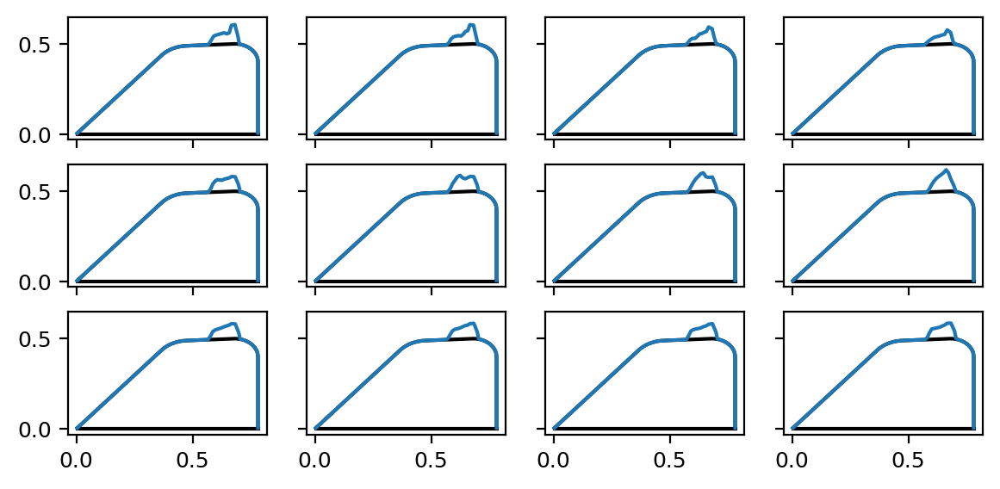

In [19]:
## Plot contact surface pressure profiles (spatial/fancy plot)
if FIG_TYPE == 'manuscript':
    fig, axs = plt.subplots(len(MESH_NAMES), len(SCAR_DIAS), figsize=(FIG_LX_WIDE, 8*CM), sharex=True, sharey=True)
elif FIG_TYPE == 'presentation':
    fig, axs = plt.subplots(len(MESH_NAMES), len(SCAR_DIAS), figsize=(FIG_LX_WIDE, FIG_LY), sharex=True, sharey=True)

# Define grid spacing
gs = mpl.gridspec.GridSpec(2, len(MESH_NAMES), height_ratios=[0.1, 1], hspace=0.05)

# iM = index_Mesh, iS = index_Scar
for iM in range(0, len(MeshNames)):
    for iS in range(0, len(ScarDias)):   
        xy_med = facet_coords[iM][iS]
        nn_med = normal(xy_med)
        # Plot VF mesh outline
        axs[iM, iS].plot(xy_med[:, 0], xy_med[:, 1], color='k')
        axs[iM, iS].plot(xy_med[[0, -1], 0], [0, 0], color='k')

        pc_medial = dat[iM][iS][facet_cell_neighbour_dofs[iM][iS]]
        
        scale = -0.2e-3
        pc_norm = [[0, 0] for i in range(len(pc_medial))]
        for iPC in range(0, len(pc_medial)):
            pc_norm[iPC][0] = scale*pc_medial[iPC]*nn_med[iPC][0]
            pc_norm[iPC][1] = scale*pc_medial[iPC]*nn_med[iPC][1]
            # print(scale*pc_medial[iPC]*nn_med[iPC, 0])
            # print(scale*pc_medial[iPC]*nn_med[iPC, 1])            
        
        # pc_n = offset_normal(xy_med, scale*pc_medial*nn_med)
        pc_n = offset_normal(xy_med, pc_norm)
        axs[iM, iS].plot(pc_n[:, 0], pc_n[:, 1])


# ## PLot contact surface pressure profiles
# if FIG_TYPE == 'presentation':
#     fig = plt.figure(figsize=(FIG_LX_WIDE, FIG_LY))
# elif FIG_TYPE == 'manuscript':
#     fig = plt.figure(figsize=(FIG_LX_WIDE, 0.3*FIG_LY))
# gs = mpl.gridspec.GridSpec(2, 3, height_ratios=[0.1, 1], hspace=0.05)

# ax_legend = fig.add_subplot(gs[0, :])
# axs = np.array([fig.add_subplot(gs[1, ii]) for ii in range(gs.ncols)])

# for ax in axs:
#     ax.sharex(axs[0])
#     ax.sharey(axs[0])

# ax_legend.set_axis_off()
# for ax in axs[1:]:
#     ax.tick_params(labelleft=False)

# # fig, axs = plt.subplots(1, 3, figsize=(FIG_LX_WIDE, 6*CM), sharex=True, sharey=True)

# s = model.fluid.s
# xy_med = facet_coords
# nn_med = normal(xy_med)
# for ax in axs:
#     ax.plot(xy_med[:, 0], xy_med[:, 1], color='k')
#     ax.plot(xy_med[[0, -1], 0], [0, 0], color='k')
#     ax.set_aspect(1)

# for ax, mcov in zip(axs, mcovs):
#     for vcov, pc in zip(vcovs, dat[mcov]):
#         pc_medial = pc[facet_cell_neighbor_dofs]
#         scale = -0.2

#         pc_n = offset_normal(xy_med, scale*pc_medial[:, None]*nn_med)
#         ax.plot(pc_n[:, 0], pc_n[:, 1], label=f"$v$={vcov:.2f}")

#         # average contact pressure field
#         # ax.plot(s, pc_medial, label=f"$v$={vcov:.1f}")

# N = 25
# for ax, mcov in zip(axs, mcovs):
#     dxy = np.max(dat[mcov])*scale*nn_med[N]
#     ax.arrow(*xy_med[N], *dxy, head_width=0)
#     pad = np.array([-0.01, 0])
#     ax.text(*(xy_med[N] + dxy/4 + pad), f"{np.max(dat[mcov]):.2f} [kPa]", ha='right')
#     ax.text(0.05, 0.95, f"$m'={mcov:.2f}$", transform=ax.transAxes, va='top', ha='left')

# axs[0].set_ylabel("$y$ [cm]")


# labels = [f"$v={v:.2f}$" for v in vcovs]
# lines = [mpl.lines.Line2D([0], [0], color=color) for color in COLOR_CYCLE]
# ax_legend.legend(lines, labels, loc='lower left', ncol=len(lines))
# # axs[0].legend(loc=(0, 1.05), ncol=1, ax=ax_legend)
# # axs[0].legend()

# for ax in axs:
#     ax.set_xlim(0.2, 0.8)
#     ax.set_ylim(0.2, 0.7)
#     ax.set_xlabel("x [cm]")

# fig.tight_layout()
# fig.savefig(f'{FIG_DIR}/ContactPressureFieldVsV-Fancy.{FIG_EXT}')

## 2D Stress Fields

TypeError: Invalid shape () for image data

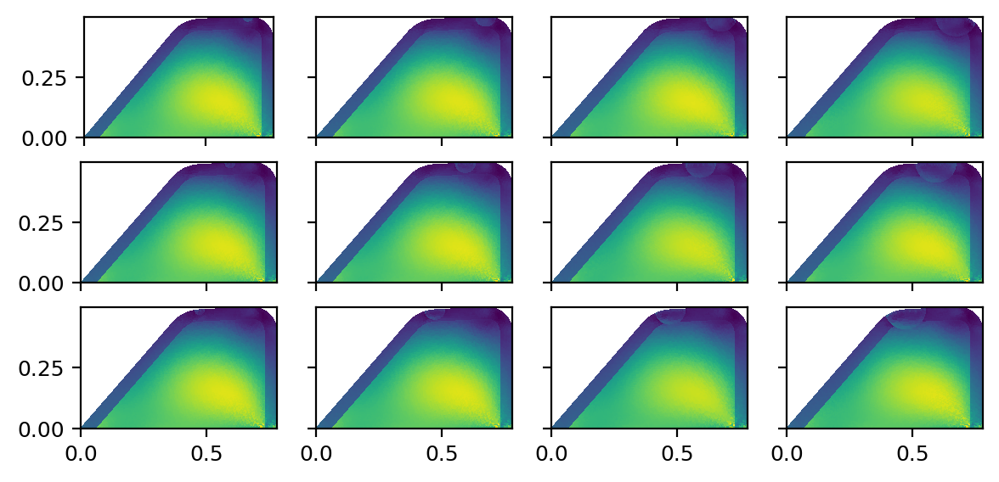

In [20]:
# Obtaining 2D stress field plots for each case
import matplotlib.colorizer as mcolorizer
import matplotlib.colors as mcolors

if FIG_TYPE == 'manuscript':
    fig, axs = plt.subplots(len(MESH_NAMES), len(SCAR_DIAS), figsize=(FIG_LX_WIDE, 8*CM), sharex=True, sharey=True)
elif FIG_TYPE == 'presentation':
    fig, axs = plt.subplots(len(MESH_NAMES), len(SCAR_DIAS), figsize=(FIG_LX_WIDE, FIG_LY), sharex=True, sharey=True)

# Define grid spacing
gs = mpl.gridspec.GridSpec(2, len(MESH_NAMES), height_ratios=[0.1, 1], hspace=0.05)

field_names = [
    'field.tavg_vm',
    'field.tavg_hydrostatic',
    'field.tini_vm',
    'field.tini_hydrostatic'
    # 'field_fp_vm',
    # 'field_fp_hydrostatic',
]

field_dat = [[{} for i in range(len(ScarDias))] for j in range(len(MeshNames))]
ys = [[[] for i in range(len(ScarDias))] for j in range(len(MeshNames))]

# iM = index_Mesh, iS = index_Scar
for iM in range(0, len(MeshNames)):
    for iS in range(0, len(ScarDias)):
        field_dat[iM][iS] = {
            # Only measurement name is needed for key since geometric parameters are handled by the outer 2D array
            f'{field_name}': load_measures_np(SIGNALS, f'{field_name}', {'MeshName': MeshNames[iM], 'SD': ScarDias[iS]})
            for field_name in field_names
        }
        
        # VERT_TO_VDOF, CELLS are defined early on in notebook when loading model info, dependent on the meshes
        XREF_VERT = XREF[iM][iS][VERT_TO_VDOF[iM][iS]].reshape(-1, 2)
        trian = tri.Triangulation(XREF_VERT[:, 0], XREF_VERT[:, 1], CELLS[iM][iS])

        ys[iM][iS] = np.array([
            # Convert field_dat vals to kPa
            field_dat[iM][iS][f'field.tavg_vm']/10/1e3
        ])

        ys_abs = ys[iM][iS][0]

        # Hardcoding the plot_tripcolor_seq because of issues with working with current axs implementation
        zmin = np.min(ys_abs)
        zmax = np.max(ys_abs)
        kwargs = {'vmin': zmin, 'vmax': zmax, 'edgecolors': 'none'}
        
        fspace_cg1 = dfn.FunctionSpace(MODEL[iM][iS].solid.residual.mesh(), 'CG', 1)#forms['fspace.scalar']
        fspace_dg0 = dfn.FunctionSpace(MODEL[iM][iS].solid.residual.mesh(), 'DG', 0)
        z_cg1 = dfn.Function(fspace_cg1)
        z_dg0 = dfn.Function(fspace_dg0)
    
        ys_abs_flat = ys_abs.reshape(-1, ys_abs.shape[-1])
        artists = axs[iM, iS].tripcolor(trian, ys_abs, **kwargs)
    
        ## Project the dg0 stress to CG1 so you can plot contours
        z_dg0.vector()[:] = ys_abs
        z_vertex = dfn.project(z_dg0, fspace_cg1, function=z_cg1).vector()[VERT_TO_SDOF[iM][iS]]
        # Setting 'Greys' cmap and vmin/vmax appropriately will ensure a specific color for the contour line
        # cmap = plt.get_cmap(name='Greys')
        axs[iM, iS].tricontour(trian, z_vertex, [0], colors=['k'], linewidths=[1])
        
        # artists_abs = plot_tripcolor_seq(iM, iS, axs, trian, ys_abs, zmax=None)

# TODO fix legend for colour plots
# create a colorizer with a predefined norm to be shared across all images
norm = mcolors.Normalize(vmin=np.min(ys[iM][iS][0]), vmax=np.max(ys[iM][iS][0]))
colorizer = mcolorizer.Colorizer(norm=norm)

images = []
for ax, data in zip(axs.flat, ys[iM][iS][0]):
    images.append(ax.imshow(data, colorizer=colorizer))
    
# ax_cbar_abs.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
# ax_cbar_abs.set_xlabel(r"$\tilde{\sigma}_\mathrm{vm}$ [kPa]")

# cbar = fig.colorbar(axs[iM, iS], ax_cbar_abs, orientation='horizontal')
# cbar = fig.colorbar(ax=axs, ax_cbar_abs, orientation='horizontal', fraction=.1)
fig.colorbar(images[0], ax=axs, orientation='horizontal', fraction=.1)
        


In [121]:
def plot_tripcolor_seq(iM, iS, axs, trian, zdata, zmin=None, zmax=None):
    # iM, iS needed for calling indices of MODEL, VERT_TO_SDOF and axs variables, 
    """
    Plot a sequence of `tripcolor` data with shared z limits

    By default, all plots are normalized between the min/max of all z data.

    Parameters
    ----------
    axs : mpl.axes.Axes
        An array of axes to plot in
    trian : mpl.triangulation.Triangulation
        The triangulation used for data
    zdata : List[np.ndarray]
        A list of z data for each tri-plot

    Returns
    -------
    List[mpl.artist.Artist]
        A list of artists for each `tripcolor` call. You can use any of the
        artists to create a colorbar since they have the same normalization.
    """
    if zmin is None:
        zmin = np.min(zdata)
    if zmax is None:
        zmax = np.max(zdata)
    kwargs = {'vmin': zmin, 'vmax': zmax, 'edgecolors': 'none'}
    
    # TODO need to change to for loop (or pass constraints in) and change model, VERT_TO_SDOF to the 2d array versions
    # Changed model to MODEL[iM][iS]
    fspace_cg1 = dfn.FunctionSpace(MODEL[iM][iS].solid.residual.mesh(), 'CG', 1)#forms['fspace.scalar']
    fspace_dg0 = dfn.FunctionSpace(MODEL[iM][iS].solid.residual.mesh(), 'DG', 0)
    z_cg1 = dfn.Function(fspace_cg1)
    z_dg0 = dfn.Function(fspace_dg0)

    zdata_flat = zdata.reshape(-1, zdata.shape[-1])
    for z, ax in zip(zdata_flat, axs.flat):
        artists = ax.tripcolor(trian, z, **kwargs)
        # ax.tricontour(trian, y, [0])

        ## Project the dg0 stress to CG1 so you can plot contours
        # print(y_dg0.vector().size(), y.shape)
        z_dg0.vector()[:] = z
        # Changed VERT_TO_SDOF to VERT_TO_SDOF[iM][iS]
        z_vertex = dfn.project(z_dg0, fspace_cg1, function=z_cg1).vector()[VERT_TO_SDOF[iM][iS]]
        # Setting 'Greys' cmap and vmin/vmax appropriately will ensure a specific color for the contour line
        # cmap = plt.get_cmap(name='Greys')
        ax.tricontour(trian, z_vertex, [0], colors=['k'], linewidths=[1])
    return artists

#######################################################################
# Specify the case(s) of interest
field_names = [
    'field.tavg_vm',
    'field.tavg_hydrostatic',
    'field.tini_vm',
    'field.tini_hydrostatic'
    # 'field_fp_vm',
    # 'field_fp_hydrostatic',
]

field_dat = [[{} for i in range(len(ScarDias))] for j in range(len(MeshNames))]

# iM = index_Mesh, iS = index_Scar
for iM in range(0, len(MeshNames)):
    for iS in range(0, len(ScarDias)):
        field_dat[iM][iS] = {
            # Only measurement name is needed since geometric parameters are handled by the outer 2D array
            f'{field_name}': load_measures_np(SIGNALS, f'{field_name}', {'MeshName': MeshNames[iM], 'SD': ScarDias[iS]})
            for field_name in field_names
        }
        
        # VERT_TO_VDOF, CELLS are defined early on in notebook when loading model info, dependent on the meshes
        XREF_VERT = XREF[iM][iS][VERT_TO_VDOF[iM][iS]].reshape(-1, 2)
        trian = tri.Triangulation(XREF_VERT[:, 0], XREF_VERT[:, 1], CELLS[iM][iS])

        ys = np.array([
            # Convert field_dat vals to kPa
            field_dat[iM][iS][f'field.tavg_vm']/10/1e3
        ])
        # Verify ys is proper shape
        # .reshape(len(mcovs), len(vcovs), -1)
        ys_abs = ys[0]



        # Hardcoding the plot_tripcolor_seq
        if zmin is None:
            zmin = np.min(ys_abs)
        if zmax is None:
            zmax = np.max(ys_abs)
        kwargs = {'vmin': zmin, 'vmax': zmax, 'edgecolors': 'none'}
        
        # TODO need to change to for loop (or pass constraints in) and change model, VERT_TO_SDOF to the 2d array versions
        # Changed model to MODEL[iM][iS]
        fspace_cg1 = dfn.FunctionSpace(MODEL[iM][iS].solid.residual.mesh(), 'CG', 1)#forms['fspace.scalar']
        fspace_dg0 = dfn.FunctionSpace(MODEL[iM][iS].solid.residual.mesh(), 'DG', 0)
        z_cg1 = dfn.Function(fspace_cg1)
        z_dg0 = dfn.Function(fspace_dg0)
    
        zdata_flat = zdata.reshape(-1, zdata.shape[-1])
        for z, ax in zip(zdata_flat, axs.flat):
            artists = ax.tripcolor(trian, z, **kwargs)
            # ax.tricontour(trian, y, [0])
    
            ## Project the dg0 stress to CG1 so you can plot contours
            # print(y_dg0.vector().size(), y.shape)
            z_dg0.vector()[:] = z
            # Changed VERT_TO_SDOF to VERT_TO_SDOF[iM][iS]
            z_vertex = dfn.project(z_dg0, fspace_cg1, function=z_cg1).vector()[VERT_TO_SDOF[iM][iS]]
            # Setting 'Greys' cmap and vmin/vmax appropriately will ensure a specific color for the contour line
            # cmap = plt.get_cmap(name='Greys')
            ax.tricontour(trian, z_vertex, [0], colors=['k'], linewidths=[1])
        
        artists_abs = plot_tripcolor_seq(iM, iS, axs, trian, ys_abs, zmax=None)

        cbar = fig.colorbar(artists_abs, cax=ax_cbar_abs, orientation='horizontal')
        ax_cbar_abs.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
        ax_cbar_abs.set_xlabel(r"$\tilde{\sigma}_\mathrm{vm}$ [kPa]")



        
# ## TODO change to obtain data for iM and iS
# dat = {
#     f'{mcov:.2e}/{meas_name}': load_measures(SIGNALS, f'{meas_name}', {'vcov': vcovs, 'mcov': mcov})
#     for meas_name in meas_names
#     for mcov in mcovs
# }


######################################################################

## Looks like debug statement, dont need
# dat[f'{mcov:.2e}/field.tavg_vm']



######################################################################


# mcovs=[-0.8]

figsize = (FIG_LX_WIDE, 13*CM)
# fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize=figsize)

# ncol = len(vcovs)
# nrow = len(mcovs)

if FIG_TYPE == 'manuscript':
    fig, axs = plt.subplots(len(MESH_NAMES), len(SCAR_DIAS), figsize=(FIG_LX_WIDE, 8*CM), sharex=True, sharey=True)
elif FIG_TYPE == 'presentation':
    fig, axs = plt.subplots(len(MESH_NAMES), len(SCAR_DIAS), figsize=(FIG_LX_WIDE, FIG_LY), sharex=True, sharey=True)

# Define grid spacing
# gs = mpl.gridspec.GridSpec(2, len(MESH_NAMES), height_ratios=[0.1, 1], hspace=0.05)

gs = mpl.gridspec.GridSpec(
    len(MESH_NAMES)+2, len(SCAR_DIAS)+1,
    width_ratios=[1]*len(SCAR_DIAS) + [0.05],
    height_ratios=[0.05]*2+[1]*len(MESH_NAMES)
)

## TODO make different plots for abs and diff?
ax_cbar_abs = fig.add_subplot(gs[0, 0])
ax_cbar_diff = fig.add_subplot(gs[0, 1])

for iM in range(0, len(MeshNames)):
    for iS in range(0, len(ScarDias)):

        # VERT_TO_VDOF, CELLS are defined early on in notebook when loading model info, dependent on the meshes
        XREF_VERT = XREF[iM][iS][VERT_TO_VDOF[iM][iS]].reshape(-1, 2)
        trian = tri.Triangulation(XREF_VERT[:, 0], XREF_VERT[:, 1], CELLS[iM][iS])

        ys = np.array([
            # Convert field_dat vals to kPa
            field_dat[iM][iS][f'field.tavg_vm']/10/1e3
        ])
        # Verify ys is proper shape
        # .reshape(len(mcovs), len(vcovs), -1)
        ys_abs = ys[0]
        artists_abs = plot_tripcolor_seq(iM, iS, axs, trian, ys_abs, zmax=None)

        cbar = fig.colorbar(artists_abs, cax=ax_cbar_abs, orientation='horizontal')
        ax_cbar_abs.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
        ax_cbar_abs.set_xlabel(r"$\tilde{\sigma}_\mathrm{vm}$ [kPa]")

        # diff variables broken, calling ys[1:] does not work, need to redo how arrays are called
        # ys_diff = ys[1:] - ys[0:1]
        # ys_diff_percent = ys_diff/ys[0:1]

        # changs axs and ys_abs
        # artists_diff = plot_tripcolor_seq(iM, iS, axs, trian, ys_diff, zmax=0.3)

        # cbar = fig.colorbar(artists_diff, cax=ax_cbar_diff, orientation='horizontal')
        # ax_cbar_diff.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
        # ax_cbar_diff.set_xlabel(r"$\Delta \tilde{\sigma}_\mathrm{vm}$ [kPa]")


# ys = np.array([
#     dat[f'{mcov:.2e}/field.tavg_vm'][ii]/10/1e3
#     for mcov in mcovs
#     for ii in range(len(vcovs))
# ]).reshape(len(mcovs), len(vcovs), -1)
# ys_diff = ys[:, 1:] - ys[:, 0:1]
# ys_diff_percent = (ys[:, 1:] - ys[:, 0:1])/ys[:, 0:1]
# artists_diff = plot_tripcolor_seq(axs[:, 1:], trian, ys_diff, zmax=0.3)

# ys_abs = ys[:, 0]
# artists_abs = plot_tripcolor_seq(axs[:, 0], trian, ys_abs, zmax=None)

# for ax, vcov in zip(_axs[1:], vcovs[1:]):
#     ax.text(0.05, 0.95, f"$v={vcov:.2f}$\n$m'={mcov:.2f}$", transform=ax.transAxes, ha='left', va='top')

# ys_abs = np.array([y-ys[0] for y in ys[1:]])
# artists_diff = plot_tripcolor_seq(_axs[1:], trian, ys_diff)

# Add annotations for changing v + m
ax = fig.add_subplot(gs[1, :-1])
ax.axis('off')
ax.annotate(
    "increasing swelling", ha='right', va='center',
    xytext=(0.4, 1.3), xy=(.6, 1.3), xycoords=ax.transAxes,
    arrowprops={'arrowstyle':'simple', 'fc': 'black'}
)

ax = fig.add_subplot(gs[2:, -1])
ax.axis('off')
ax.annotate(
    "increasing softening", ha='center', va='bottom', rotation=-90,
    xytext=(1.15, 0.6), xy=(1.15, 0.4), xycoords=ax.transAxes,
    arrowprops={'arrowstyle':'simple', 'fc': 'black'},
)

for ax in axs.flat:
    ax.set_aspect(1, adjustable='box')

for ax in axs[:, 1:].flat:
    ax.tick_params(axis='y', labelleft=False)

for ax in axs[:-1, :].flat:
    ax.tick_params(axis='x', labelbottom=False)

for ax, mcov in zip(axs[:, 0], mcovs):
    ax.set_ylabel(r"y [cm]")
for ax, vcov in zip(axs[-1, :], vcovs):
    ax.set_xlabel(r"x [cm]")


for ax, mcov in zip(axs[:, -1], mcovs):
    text_kwargs = {
        'transform': ax.transAxes,
        'ha': 'left',
        'va': 'center'
    }
    ax.text(1, 0.5, f"$\\bar{{m}}'={mcov:.2f}$", rotation=-90, **text_kwargs)
for ax, vcov in zip(axs[0, :], vcovs):
    text_kwargs = {
        'transform': ax.transAxes,
        'ha': 'center',
        'va': 'bottom'
    }
    ax.text(0.5, 1.0, f"\n$v$={vcov:.2f}", **text_kwargs)

fig.tight_layout()
# fig.savefig(f'{FIG_DIR}/StressFieldVsV.{FIG_EXT}')



########################################################################

NameError: name 'zdata' is not defined

TypeError: Value after * must be an iterable, not int

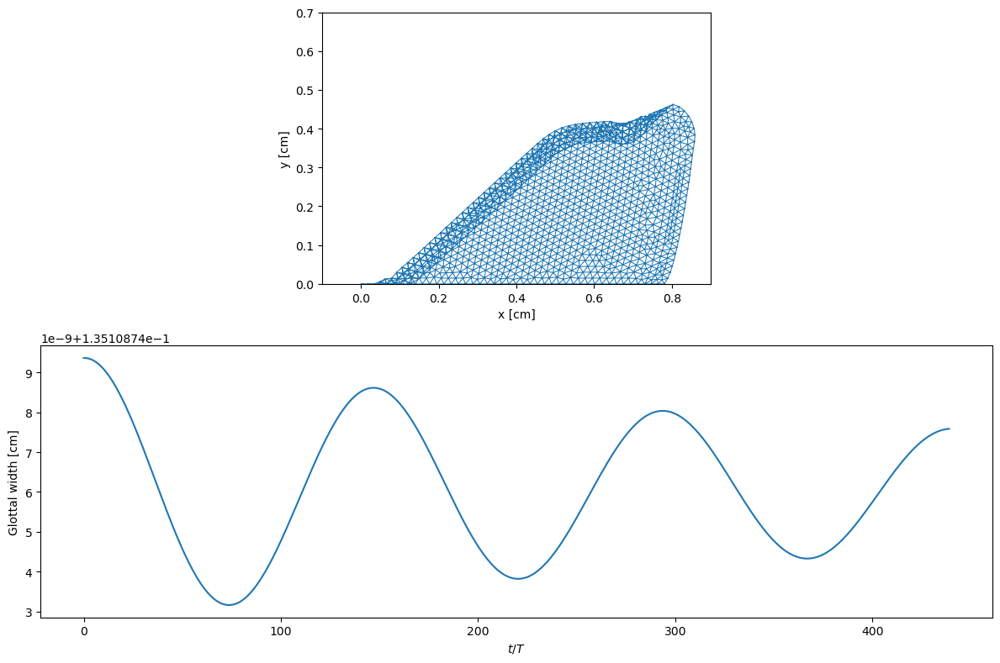

In [48]:
## Animated Video
# fnames = form_fname(MESH_NAME, ECOV, EBOD, ESCAR, VCOV, MCOV, PSUB)
# print(model.solid.forms['mesh.mesh'].coordinates().shape)

# Figure dimensions
FIG_LX_WIDE = 12
FIG_LY = 8
SIZE_SMALL = 6
from scipy.signal import find_peaks
from matplotlib import animation

def tri_to_linexy(tri):
    x, y, edges = (tri.x, tri.y, tri.edges)
    tri_lines_x = np.insert(x[edges], 2, np.nan, axis=1).ravel()
    tri_lines_y = np.insert(y[edges], 2, np.nan, axis=1).ravel()
    return tri_lines_x, tri_lines_y

def plot_update(f, t, offset, artist, dt):
    ii = int(round(t/dt))
    xcur = XREF[][] + f.get_state(offset+ii).sub['u']
    xcur_vert = xcur[VERT_TO_VDOF[][]].reshape(-1, 2)

    # mutate the triplot lines in artists[0]
    tri_frame = tri.Triangulation(xcur_vert[:, 0], xcur_vert[:, 1], CELLS)
    x, y = tri_to_linexy(tri_frame)
    artist[0].set_xdata(x)
    artist[0].set_ydata(y)
    return artist

## TODO for loop here (or add XREF_VERT 2d array object) 
XREF_VERT = XREF[][][VERT_TO_VDOF[][]].reshape(-1, 2)
trian = tri.Triangulation(XREF_VERT[:, 0], XREF_VERT[:, 1], CELLS[][])

fig = plt.figure(figsize=(FIG_LX_WIDE, FIG_LY))

# TODO change len(vcovs) to iterate through other parameters
# gs = mpl.gridspec.GridSpec(2, len(vcovs))
gs = mpl.gridspec.GridSpec(2, 1)
axs_vid = np.array([fig.add_subplot(gs[0, ii]) for ii in range(gs.ncols)])
axs_gw = np.array([fig.add_subplot(gs[1, ii]) for ii in range(gs.ncols)])
axs = np.stack([axs_vid, axs_gw], axis=0)

for ax in axs_vid.flat[1:]:
    axs_vid.flat[0].sharex(ax)
    axs_vid.flat[0].sharey(ax)

for ax in axs_gw[1:]:
    axs_gw.flat[0].sharex(ax)
    axs_gw.flat[0].sharey(ax)

# gws = [SIGNALS[param.to_str()+'/gw'][:] for fname in fnames]
gws = [SIGNALS[case_name+'/time.gw'][:] for case_name in case_names]
amps = [np.max(gw[-5000:]) for gw in gws]
last_cycle_peaks = [
    find_peaks(gw, height=0.9*amp)[0][-4:]
    for gw, amp in zip(gws, amps)
]

for ax in axs[:, 1:].flat:
    ax.tick_params(labelleft=False)
for ax in axs_vid.flat[1:]:
    ax.tick_params(labelleft=False)

for ax, gw, peaks in zip(axs_gw, gws, last_cycle_peaks):
    ax.plot(gw[peaks[0]:peaks[-1]])

for ax in axs_gw:
    ax.set_xlabel("$t/T$")
axs_gw[0].set_ylabel("Glottal width [cm]")
axs_vid[0].set_ylabel("y [cm]")

artists = [ax.triplot(trian, lw=0.75) for ax in axs_vid]
for ax in axs_vid:
    ax.set_xlabel("x [cm]")
    ax.set_aspect(1)
    ax.set_xlim(-0.1, 0.9)
    ax.set_ylim(0.0, 0.7)

fig.tight_layout()

dts = [3/(peaks[-1]-peaks[0]) for peaks in last_cycle_peaks]
offsets = [peaks[0] for peaks in last_cycle_peaks]

NFRAME = 10
with (
        sf.StateFile(MODEL[][], f'{OUT_DIR}/{case_names[0]}.h5', mode='r') as f1,
        sf.StateFile(MODEL[][], f'{OUT_DIR}/{case_names[1]}.h5', mode='r') as f2
    ):
    fs = [f1, f2]

    ii = 0
    plot_update(fs[ii], 0.0, offsets[ii], artists[ii], dts[ii])

    def _update(frame):
        _artists = []
        t = 3*frame/NFRAME
        for f, artist, offset, dt in zip(fs, artists, offsets, dts):
            _artist = plot_update(f, t, offset, artist, dt)
            _artists.append(_artist)

        return np.concatenate(_artists).tolist()

    _update(4)

    ani = animation.FuncAnimation(
        fig,
        _update,
        blit=True,
        frames=np.arange(NFRAME)
    )
    escar = scarV2.ExpParam(case_names[0])['Escar']
    # ani.save(f'{FIG_DIR}/v{vcov:.2e}_m{mcov:.2e}.mp4', dpi=300, fps=60)
    # TODO change file name to only have Escar
    ani.save(f'{FIG_DIR}/Escar{escar:.2e}.mp4', dpi=300, fps=60)

## Animate motion
fig, ax = plt.subplots(1, 1, figsize=SIZE_SMALL)
ax.set_xlim(-0.25, 1.0)
ax.set_ylim(0, 0.6)
ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")
ax.set_aspect(1.0, adjustable='box')
ax.axhline(0.55, color='k', ls='-.')
fig.tight_layout()

XREF_VERT = XREF[][][VERT_TO_VDOF[][]].reshape(-1, 2)
trian = tri.Triangulation(XREF_VERT[:, 0], XREF_VERT[:, 1], CELLS[][])
artists = ax.triplot(trian, lw=0.75)

# fname = form_fname(MESH_NAME, ECOV, EBOD, ESCAR, vcov, mcov, PSUB)
# with sf.StateFile(model, f'{OUT_DIR}/{fname}.h5', mode='r') as f:


with sf.StateFile(model, f'{OUT_DIR}/{fname}.h5', mode='r') as f:
    def _plot_update(frame):
#         xcur = XREF + f.get_state(frame)['u']
#         xcur_vert = xcur[VERT_TO_VDOF].reshape(-1, 2)

#         # mutate the triplot lines in artists[0]
#         tri_frame = tri.Triangulation(xcur_vert[:, 0], xcur_vert[:, 1], CELLS)
#         x, y = tri_to_linexy(tri_frame)
#         artists[0].set_xdata(x)
#         artists[0].set_ydata(y)
        dt = 1
        offset = 0
        return plot_update(f, frame, offset, artists, dt)
        # return artists
    # plot_update(1000)

    ani = animation.FuncAnimation(
        fig,
        _plot_update,
        blit=True,
        frames=f.size + np.arange(-1000, 0)
    )
    ani.save(f'{FIG_DIR}/v{vcov:.2e}_m{mcov:.2e}.mp4', dpi=450, fps=60)

### Mesh for Inkscape/schematic

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# ⛔ Disable LaTeX to prevent 'PermissionError: [Errno 13] Permission denied: latex'
mpl.rcParams['text.usetex'] = False

# 📏 Define CM conversion
CM = 1 / 2.54  # 1 cm in inches

# 📐 Create figure with desired size
fig, ax = plt.subplots(1, 1, figsize=(8.4 * CM, 8.4 * CM))
ax.set_aspect('equal')

# 🔢 Compute vertex coordinates
xy_vert = np.array(XREF)[VERT_TO_VDOF].reshape(-1, 2)
print("xy_vert shape:", xy_vert.shape)

# 🔺 Plot the triangulated mesh
ax.triplot(*xy_vert.T, triangles=CELLS, lw=0.5, color='black')

# 🧼 Clean layout (without tight_layout to avoid LaTeX)
fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01)

# 🖼 Save SVG output
fig.savefig(f'{FIG_DIR}/Mesh.svg', format='svg', bbox_inches='tight')
plt.close(fig)

xy_vert shape: (1116, 2)


### Onset swelling plots

In [209]:
from libhopf import functional
from libhopf import signal
from libhopf import hopf

DYN_MODEL = load_dynamical_fsi_model(
    mesh_path,
    None,
    SolidType=dsolid.SwellingKelvinVoigtWEpitheliumNoShape,
    FluidType=dfluid.BernoulliAreaRatioSep
)
LDYN_MODEL = load_dynamical_fsi_model(
    mesh_path,
    None,
    SolidType=dsolid.SwellingKelvinVoigtWEpitheliumNoShape,
    FluidType=dfluid.LinearizedBernoulliAreaRatioSep
)
sys.path.append('/home/nhewko/FEniCS/vf-onset-sensitivity/src/libhopf')
#import hopf
HOPF_MODEL = hopf.HopfModel(DYN_MODEL, LDYN_MODEL)

NameError: name 'mesh_path' is not defined

In [208]:
#%debug

## Set basic model parameters

# This sets the properties based on the 'scarV2.py' script that runs the sims.
params_dict = PARAMS_DEFAULT.data.copy()
params_dict['vcov'] = 1.15
params_dict['mcov'] = 0
params = ExpParam(params_dict)
prop = scarV2.setup_basic_props( params, DYN_MODEL)
# prop.print_summary()

# Manually change properties you want to check here
mesh_coords = DYN_MODEL.solid.residual.mesh().coordinates()
ymax = mesh_coords[:, 1].max()

ygap = 0.03
prop['ycontact'] = ymax + 9/10*ygap
prop['ymid'] = ymax + ygap
for n in range(len(DYN_MODEL.fluids)):
        prop[f'fluid{n}.area_lb'] = 2*1/10*ygap

# prop['nu'] = 0.4999
# prop['emod_membrane'] = 0e3*10
# prop['emod'][cells_cover] = 2.5e3*10

# prop.print_summary()

NameError: name 'DYN_MODEL' is not defined

In [26]:
## Solve for the displacement with swelling
MODEL.set_prop(prop)
nload = 25

# MODEL.solid.control.print_summary()

state_fp, solve_info = scarV2.solve_static_swollen_config(
    MODEL.solid, MODEL.solid.control, MODEL.solid.prop, nload
)
print(solve_info)
state0 = MODEL.solid.state0.copy()
state0[:] = 0

def assem_res():
    res = dfn.assemble(MODEL.solid.forms['form.un.f1uva'])
    MODEL.solid.forms['bc.dirichlet'].apply(res)
    return res

MODEL.solid.set_fin_state(state0)
#print(assem_res().norm('l2'))
MODEL.solid.set_fin_state(state_fp)
#print(assem_res().norm('l2'))

statefp_0 = DYN_MODEL.state.copy()
statefp_0[:] = 0
statefp_0['u'] = state_fp['u']

{'num_iter': 0, 'status': 0, 'message': 'solver converged', 'abs_errs': array([0.]), 'rel_errs': array([0.])}


ValueError: could not broadcast input array from shape (2232,) into shape (1696,)

In [27]:
def solve_fp_r(res, control, prop):
    # Generate a swollen deformation as the initial guess for a fixed-point
    res.set_prop(prop)
    sl_control = res.solid.control
    sl_control[:] = 0

    nload = int(20*np.max(prop['v_swelling'])/1.3)
    sl_state_swollen, solve_info = scarV2.solve_static_swollen_config(
        res.solid, sl_control, res.solid.prop, nload
    )
    if solve_info['status'] == -1:
        raise RuntimeError(
            "Static swollen deformation could not be computed with info: "
            f"{solve_info}"
        )

    # Use the static swollen state as the initial guess for solving the
    # fixed-point
    xfp_0 = res.state.copy()
    xfp_0[:] = 0
    xfp_0['u'] = sl_state_swollen['u']
    xfp_n, solve_info = libhopf.solve_fp(res, control, prop, xfp_0=xfp_0, psub_incr=1e4)
    if solve_info['status'] == -1:
        raise RuntimeError(
            "Fixed point could not be computed with info: "
            f"{solve_info}"
        )

    return xfp_n, solve_info

In [28]:
# Quick test to see if `solve_fp_r` works
control = DYN_MODEL.control.copy()
for n in range(len(MODEL.fluids)):
        control[f'fluid{n}.psub'] = param['psub']
        control[f'fluid{n}.psup'] = 0.0
solve_fp_r(DYN_MODEL, control, prop)

ValueError: Can't assign input values with bshape ((2104, 2104, 2104, 2104, 2104, 1, 2104, 2104, 2104, 1, 2, 1, 1, 1, 1, 1),) to array with bshape ((1588, 1588, 1588, 1588, 1588, 1, 1588, 1588, 1588, 1, 2, 1, 1, 1, 1, 1),)

#### Plot growth rate vs psub

In [29]:
## Compute the growth rate vs. psub
psubs = np.arange(10, 501, 100)*10
control = DYN_MODEL.control.copy()
def set_control(control, psub):
    control['psub'] = psub
    return control
gammas = np.array([
    hopf.solve_least_stable_mode(
        DYN_MODEL,
        solve_fp_r(DYN_MODEL, set_control(control, psub), prop)[0],
        set_control(control, psub),
        prop
    )[0]
    for psub in tqdm(psubs)
])

  0%|          | 0/5 [00:00<?, ?it/s]

KeyError: 'psub'

NameError: name 'gammas' is not defined

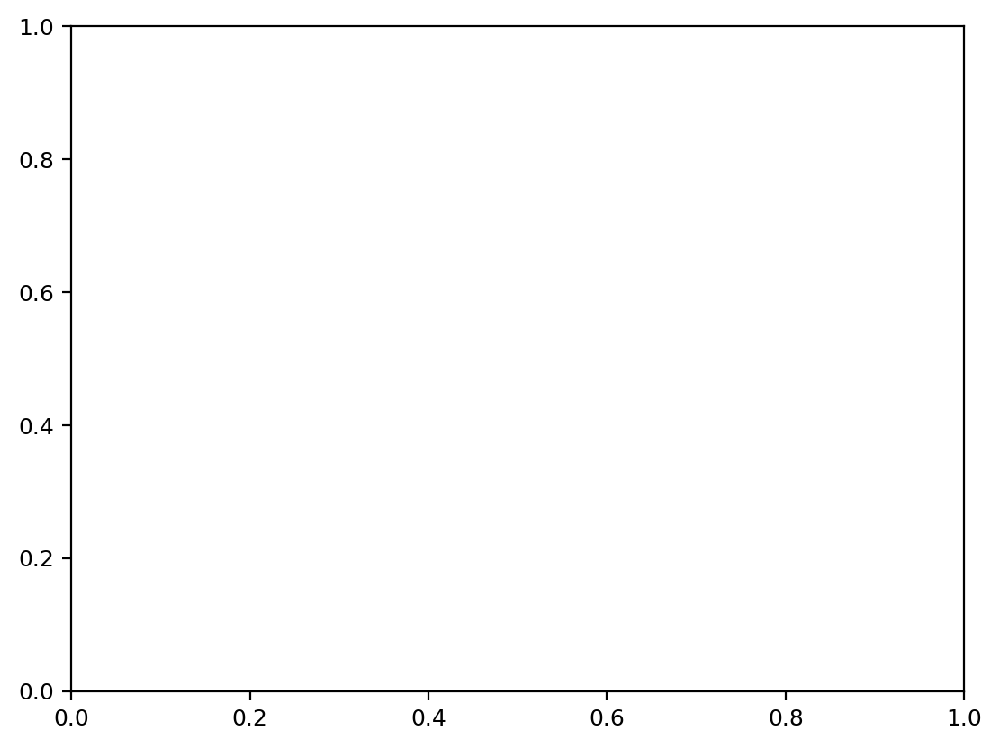

In [30]:
fig, ax = plt.subplots(1, 1)

ax.plot(psubs/10, gammas.real)
ax.axhline(0, ls='-.')
ax_twin = ax.twinx()
ax_twin.plot(psubs/10, gammas.imag/2/np.pi, color=COLOR_CYCLE[1])

ax.set_ylabel("$\omega_\mathrm{real}$", color=COLOR_CYCLE[0])
ax_twin.set_ylabel("$\omega_\mathrm{imag}$ [Hz]", color=COLOR_CYCLE[1])
ax.set_xlabel("$p_\mathrm{sub}$ [Pa]")

#### Onset pressure trend with swelling

In [ ]:
def hopf_from_v(vv, gap_compensation=False):
    params_dict = PARAMS_DEFAULT.data.copy()
    params_dict['vcov'] = vv
    params_dict['mcov'] = 0
    params = ExpParam(params_dict)
    prop = scarV2.set_basic_props(DYN_MODEL, params)

    # Compute `ymax` when accounting for swelling induced prephonatory gap changes
    DYN_MODEL.set_prop(prop)
    control = DYN_MODEL.solid.control
    control[:] = 0
    state_swollen, info = scarV2.solve_static_swollen_config(
        DYN_MODEL.solid, control, DYN_MODEL.solid.prop, nload=10
    )
    if gap_compensation:
        ymax = (DYN_MODEL.solid.XREF + state_swollen.sub['u'])[1::2].max()
    else:
        ymax = DYN_MODEL.solid.XREF[1::2].max()

    # Manually change properties here
    ygap = 0.03
    prop['ycontact'] = ymax + ygap - 1/10*ygap
    prop['ymid'] = ymax + ygap
    prop['area_lb'] = 2*1/10*ygap

    psubs = np.arange(10, 301, 100)*10
    xhopf_0 = HOPF_MODEL.state.copy()
    xhopf_0[:] = libhopf.gen_xhopf_0(
        HOPF_MODEL.res, prop, HOPF_MODEL.E_MODE, psubs, solve_fp_r=solve_fp_r
    )

    xhopf, info = libhopf.solve_hopf_by_newton(HOPF_MODEL, xhopf_0, prop)
    return xhopf

def ponset_from_v(vv, gap_compensation=False):
    xhopf = hopf_from_v(vv, gap_compensation)
    return xhopf.sub['psub'][0]

In [ ]:
# %debug
vvs = np.array([1.0, 1.1, 1.2, 1.3])

# vvs = np.array([1.3])
xhopfs_ngap = [hopf_from_v(vv, False) for vv in tqdm(vvs)]
xhopfs_ygap = [hopf_from_v(vv, True) for vv in tqdm(vvs)]

ponsets_ngap = np.array([xhopf.sub['psub'] for xhopf in xhopfs_ngap])
ponsets_ygap = np.array([xhopf.sub['psub'] for xhopf in xhopfs_ygap])

fonsets_ngap = np.array([xhopf.sub['omega'] for xhopf in xhopfs_ngap])/(2*np.pi)
fonsets_ygap = np.array([xhopf.sub['omega'] for xhopf in xhopfs_ygap])/(2*np.pi)

if FIG_TYPE == 'presentation':
    figsize = (FIG_LX_WIDE, FIG_LY)
else:
    figsize = (FIG_LX, 0.25*FIG_LY)
fig, axs = plt.subplots(1, 2, figsize=figsize)

ax_p = axs[0]
ax_p.plot(vvs, ponsets_ngap/10, label="$\\bar{{m}}'=-0.8$")

ax_f = axs[1]
ax_f.plot(vvs, fonsets_ngap, label="$\\bar{{m}}'=-0.8$")

ax_p.set_xlabel("$v$")
ax_f.set_xlabel("$v$")
ax_p.set_ylabel("$p_\mathrm{on}$ [Pa]")
ax_f.set_ylabel("$f_\mathrm{on}$ [Hz]")
ax_p.legend()
# for ax in axs.flat:
#     ax.legend()

# ax_p.xaxis.set_tick_params(labelbottom=False)

fig.tight_layout()

fig.savefig(f'{FIG_DIR}/OnsetPressureVsSwellingPresentation.{FIG_EXT}')

In [ ]:
if FIG_TYPE == 'presentation':
    figsize = (FIG_LX_WIDE, FIG_LY)
else:
    figsize = (FIG_LX, 0.25*FIG_LY)
fig, axs = plt.subplots(1, 2, figsize=figsize)

ax_p = axs[0]
ax_p.plot(vvs, ponsets_ngap/10, label="variable prephonatory gap")
ax_p.plot(vvs, ponsets_ygap/10, label="constant prephonatory gap")

ax_f = axs[1]
ax_f.plot(vvs, fonsets_ngap, label="variable prephonatory gap")
ax_f.plot(vvs, fonsets_ygap, label="constant prephonatory gap")

ax_p.set_xlabel("$v$")
ax_f.set_xlabel("$v$")
ax_p.set_ylabel("$p_\mathrm{on}$ [Pa]")
ax_f.set_ylabel("$f_\mathrm{on}$ [Hz]")
ax_p.legend()
# for ax in axs.flat:
#     ax.legend()

# ax_p.xaxis.set_tick_params(labelbottom=False)

fig.tight_layout()

fig.savefig(f'{FIG_DIR}/OnsetPressureVsSwelling.{FIG_EXT}')

dx_cover = get_dx(MODEL, 'cover')
def_grad = ufl.grad(MODEL.solid.forms['coeff.state.u1'])
j = ufl.det(def_grad + dfn.Identity(2))

MODEL.solid.set_fin_state(state0)
v0 = dfn.assemble(j*dx_cover)

MODEL.solid.set_fin_state(state_fp)
v1 = dfn.assemble(j*dx_cover)

print(v0, v1, v1/v0)

#### DEBUG - weird behaviour at high psub for finding fixed points

The fixed point solution seems to be unstable at high $p_{sub}$ for unclear reasons.

In [ ]:
psub = 100*10
control = DYN_MODEL.control.copy()
control['psub'] = psub
xfp, info = libhopf.solve_fp(DYN_MODEL, control, prop, xfp_0=statefp_0, psub_incr=1e4, method='newton')
print(info)
xfp.print_summary()

DYN_MODEL.set_state(xfp)
DYN_MODEL.set_prop(prop)
DYN_MODEL.fluid.control.print_summary()

xref = DYN_MODEL.solid.forms['mesh.mesh'].coordinates()
u = np.array(xfp.sub['u'])[VERT_TO_VDOF].reshape(-1, 2)
xcur = xref+u

print(f"xmax/ymax = ", xcur[:, 0].max(), xcur[:, 1].max())

fig, ax = plt.subplots(1, 1)

ax.triplot(xcur[:, 0], xcur[:, 1], MESH.cells())

#### Transient solution near onset

You should see that the transient solution begins self-oscillating around the
pressure where the growth rate > 0  in the above plots.

In [ ]:
# TODO: Add a small snippet to check that the transient model agrees with
# the onset prediction
print(model)
control = model.control.copy()
control[:] = 0
control['psub'] = 300*10
# control.print_summary()
# prop.print_summary()
model.dt = 1e-5
model.set_control(control)
model.set_prop(prop)
state_static, info = static.static_coupled_configuration_picard(model, control, prop)

times_vec = np.arange(0, 0.02, 5e-5)
times = blockvec.BlockVector((times_vec,))
print(times.bshape)

from femvf.postprocess.base import TimeSeries
from femvf.postprocess.solid import MinGlottalWidth

with sf.StateFile(model, 'temp.h5', mode='w') as f:
    forward.integrate(
        model, f, state_static, [control], prop, times, use_tqdm=True
    )

proc_gw = TimeSeries(MinGlottalWidth(model))
with sf.StateFile(model, 'temp.h5', mode='r') as f:
    gw = proc_gw(f)

fig, ax = plt.subplots(1, 1)
ax.plot(times_vec, gw)

### Plot glottal width signals vs. $v$

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=SIZE_SMALL)
mcov = 0
# mcov = [0,-0.4,-0.8,-1.2,-1.6]

vcovs = VCOVS[:]
# vcovs = [1.0,1.15, 1.3]

# pdefault = PARAMS_DEFAULT.substitute({'vcov': 1.0, 'psub': 600*10, 'dt': 5e-5, 'tf': 0.25})
pdefault = PARAMS_DEFAULT
# with sf.StateFile(model, f'{OUT_DIR}/{pdefault.to_str()}.h5') as f:
#     f.get_prop().print_summary()

ts = load_measures(SIGNALS, 'time', {'vcov': vcovs, 'mcov': mcov}, pdefault)
gws = load_measures(SIGNALS, 'gw', {'vcov': vcovs, 'mcov': mcov}, pdefault)
# fs = load_measures_vs_v(SIGNALS, 'fund_freq', vcovs, mcov)
for vcov, t, gw in zip(vcovs, ts, gws):
    N = gw.size
    # fund_freq, fund_phase, dfreq, dphase, info = modal.fundamental_mode_from_rfft(gw[-N:], t[1]-t[0])
    # print(gw)
    gw = gw[-N:]
    t = t[-N:]
    fund_freq, fund_phase, dfreq, dphase, info = modal.fundamental_mode_from_peaks(gw, t[1]-t[0], height=0.9*gw.max())

    # print(info[''])
    ax.plot(t, gw, label=f'$v={vcov}$, $F_0={fund_freq:.1f} \pm {dfreq:.1e} Hz$')

ax.legend(loc='lower left', bbox_to_anchor=(0, 1))
fig.tight_layout()

# ax.set_xlim(0.4, 0.5)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Glottal width [cm]")
fig.tight_layout()

fig.savefig(f'{FIG_DIR}/GlottalWidthVsV.{FIG_EXT}', dpi=200)

### Animate kinematics for a particular case

In [15]:
fnames = form_fname(MESH_NAME, ECOV, EBOD, VCOV, MCOV, PSUB)
print(model.solid.forms['mesh.mesh'].coordinates().shape)

from scipy.signal import find_peaks
from matplotlib import animation

NameError: name 'form_fname' is not defined

In [ ]:
def tri_to_linexy(tri):
    x, y, edges = (tri.x, tri.y, tri.edges)
    tri_lines_x = np.insert(x[edges], 2, np.nan, axis=1).ravel()
    tri_lines_y = np.insert(y[edges], 2, np.nan, axis=1).ravel()
    return tri_lines_x, tri_lines_y

def plot_update(f, t, offset, artist, dt):
    ii = int(round(t/dt))
    xcur = XREF + f.get_state(offset+ii).sub['u']
    xcur_vert = xcur[VERT_TO_VDOF].reshape(-1, 2)

    # mutate the triplot lines in artists[0]
    tri_frame = tri.Triangulation(xcur_vert[:, 0], xcur_vert[:, 1], CELLS)
    x, y = tri_to_linexy(tri_frame)
    artist[0].set_xdata(x)
    artist[0].set_ydata(y)
    return artist

In [ ]:
XREF_VERT = XREF[VERT_TO_VDOF].reshape(-1, 2)
trian = tri.Triangulation(XREF_VERT[:, 0], XREF_VERT[:, 1], CELLS)
vcovs=[1,1.3]

In [ ]:
fig = plt.figure(figsize=(FIG_LX_WIDE, FIG_LY))

gs = mpl.gridspec.GridSpec(2, len(vcovs))
axs_vid = np.array([fig.add_subplot(gs[0, ii]) for ii in range(gs.ncols)])
axs_gw = np.array([fig.add_subplot(gs[1, ii]) for ii in range(gs.ncols)])
axs = np.stack([axs_vid, axs_gw], axis=0)

for ax in axs_vid.flat[1:]:
    axs_vid.flat[0].sharex(ax)
    axs_vid.flat[0].sharey(ax)

for ax in axs_gw[1:]:
    axs_gw.flat[0].sharex(ax)
    axs_gw.flat[0].sharey(ax)

gws = [SIGNALS[f'{fname}/gw'][:] for fname in fnames]
amps = [np.max(gw[-5000:]) for gw in gws]
last_cycle_peaks = [
    find_peaks(gw, height=0.9*amp)[0][-4:]
    for gw, amp in zip(gws, amps)
]

for ax in axs[:, 1:].flat:
    ax.tick_params(labelleft=False)
for ax in axs_vid.flat[1:]:
    ax.tick_params(labelleft=False)

for ax, gw, peaks in zip(axs_gw, gws, last_cycle_peaks):
    ax.plot(gw[peaks[0]:peaks[-1]])

for ax in axs_gw:
    ax.set_xlabel("$t/T$")
axs_gw[0].set_ylabel("Glottal width [cm]")
axs_vid[0].set_ylabel("y [cm]")

artists = [ax.triplot(trian, lw=0.75) for ax in axs_vid]
for ax in axs_vid:
    ax.set_xlabel("x [cm]")
    ax.set_aspect(1)
    ax.set_xlim(-0.1, 0.9)
    ax.set_ylim(0.0, 0.7)

fig.tight_layout()


dts = [3/(peaks[-1]-peaks[0]) for peaks in last_cycle_peaks]
offsets = [peaks[0] for peaks in last_cycle_peaks]



NFRAME = 10
with (
        sf.StateFile(model, f'{OUT_DIR}/{fnames[0]}.h5', mode='r') as f1,
        sf.StateFile(model, f'{OUT_DIR}/{fnames[1]}.h5', mode='r') as f2
    ):
    fs = [f1, f2]

    ii = 1
    plot_update(fs[ii], 0.0, offsets[ii], artists[ii], dts[ii])

    def _update(frame):
        _artists = []
        t = 3*frame/NFRAME
        for f, artist, offset, dt in zip(fs, artists, offsets, dts):
            _artist = plot_update(f, t, offset, artist, dt)
            _artists.append(_artist)

        return np.concatenate(_artists).tolist()

    _update(4)

    ani = animation.FuncAnimation(
        fig,
        _update,
        blit=True,
        frames=np.arange(NFRAME)
    )
    ani.save(f'{FIG_DIR}/v{vcov:.2e}_m{mcov:.2e}.mp4', dpi=300, fps=60)

# for f in fs:
#     f.close()

In [ ]:
## Animate motion
fig, ax = plt.subplots(1, 1, figsize=SIZE_SMALL)
ax.set_xlim(-0.25, 1.0)
ax.set_ylim(0, 0.6)
ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")
ax.set_aspect(1.0, adjustable='box')
ax.axhline(0.55, color='k', ls='-.')
fig.tight_layout()

XREF_VERT = XREF[VERT_TO_VDOF].reshape(-1, 2)
trian = tri.Triangulation(XREF_VERT[:, 0], XREF_VERT[:, 1], CELLS)
artists = ax.triplot(trian, lw=0.75)

fname = form_fname(MESH_NAME, ECOV, EBOD, vcov, mcov, PSUB)
with sf.StateFile(model, f'{OUT_DIR}/{fname}.h5', mode='r') as f:
    def _plot_update(frame):
#         xcur = XREF + f.get_state(frame)['u']
#         xcur_vert = xcur[VERT_TO_VDOF].reshape(-1, 2)

#         # mutate the triplot lines in artists[0]
#         tri_frame = tri.Triangulation(xcur_vert[:, 0], xcur_vert[:, 1], CELLS)
#         x, y = tri_to_linexy(tri_frame)
#         artists[0].set_xdata(x)
#         artists[0].set_ydata(y)
        dt = 1
        offset = 0
        return plot_update(f, frame, offset, artists, dt)
        # return artists
    # plot_update(1000)

    ani = animation.FuncAnimation(
        fig,
        _plot_update,
        blit=True,
        frames=f.size + np.arange(-1000, 0)
    )
    ani.save(f'{FIG_DIR}/v{vcov:.2e}_m{mcov:.2e}.mp4', dpi=450, fps=60)

### Plot swollen geometries vs. $v$

In [ ]:
# Load the first state/displacement for each swelling case
# ; this is the swelling displacement because we solved for the
# static equilibrium before integrating in time
mcov = -0.8
VCOVS = [1.0, 1.15, 1.3]
GammaCov = [0.0, 5e5]
GammaBod = [0.0, 5e6]
scale = 2  # (unused here; keeping in case you use it elsewhere)

# Only keep matching gamma pairs: (gammaFbod, gammaFcov) in {(0,0), (5e5,5e4)}
allowed_gamma_pairs = {(0.0, 0.0), (5e6, 5e5)}

params = iter_params(
    {'vcov': VCOVS, 'mcov': mcov, 'gammaFcov': GammaCov, 'gammaFbod': GammaBod},
    default_params=PARAMS_DEFAULT
)

swelling_displacements = {}
for param in params:
    # Filter out unwanted gamma combinations
    if (param['gammaFbod'], param['gammaFcov']) not in allowed_gamma_pairs:
        continue

    fname = f"{OUT_DIR}/{param.to_str()}.h5"
    with sf.StateFile(model, fname) as f:
        u = f.get_state(0).sub['u']
        # Use (gammaFbod, gammaFcov, vcov) as key so both pairs are distinct
        key = (param['gammaFbod'], param['gammaFcov'], param['vcov'])
        swelling_displacements[key] = u

        prop = f.get_prop()
        prop.print_summary()


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from femvf import statefile as sf

OUT_DIR = "out"  # adjust if different

VCOVS = [1.00, 1.15, 1.30]
mcov = -0.8
scale = 2  # if you need it for other things; not used here

flow_series = {}  # {label: (t, q)}

params = iter_params({'vcov': VCOVS, 'mcov': mcov}, default_params=PARAMS_DEFAULT)
vc=1.15

for param in params:
    with sf.StateFile(model, f'{OUT_DIR}/{param.to_str()}.h5') as f:
        t = f.get_times()
        # sum q over all fluids (often just 1)
        q = np.array([
            sum(f.get_state(i)[f"fluid{n}.q"][0] for n in range(len(f.model.fluids)))
            for i in range(f.size)
        ])
    label = f"vcov={vc:.2f}"
    flow_series[label] = (t, q)

# Plot
plt.figure()
for label, (t, q) in flow_series.items():
    plt.plot(t, q, label=label)
plt.xlabel("Time [s]")
plt.ylabel("Flow rate q")
plt.title("Flow rate (Σ fluid{n}.q) vs time")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
VCOVS=[1,1.15,1.3]
scale=2

In [ ]:
key = (0.0, 0.0, 1.0)   # (gammaFbod, gammaFcov, vcov)

u_dof = swelling_displacements[key]

xcur_dof = XREF + scale * u_dof
xcur_ver = xcur_dof[VERT_TO_VDOF].reshape(-1, 2)
xcur_ver

In [ ]:
if FIG_TYPE == 'manuscript':
    fig, ax = plt.subplots(1, 1, figsize=SIZE_SMALL, sharex=True)
elif FIG_TYPE == 'presentation':
    fig, ax = plt.subplots(1, 1, figsize=(FIG_LX_WIDE/2, FIG_LY), sharex=True)

scale = 2

# Explicitly define cases: (gammaFbod, gammaFcov, vcov, style)
cases = [
    (0.0, 0.0, 1.0,  {'color': 'blue',   'ls': '-',  'label': r"$v=1.00$, no fiber"}),
    (0.0, 0.0, 1.3,  {'color': 'orange', 'ls': '-',  'label': r"$v=1.30$, no fiber, sigmoid transition of elasticity"}),
    (5e6, 5e5, 1.3,  {'color': 'red',    'ls': ':',  'label': r"$v=1.30$, fiber, sigmoid transition of elasticity"})
]

for gammaFbod, gammaFcov, vcov, style in cases:
    u_dof = swelling_displacements[(gammaFbod, gammaFcov, vcov)]
    xcur_dof = XREF + scale * u_dof
    xcur_ver = xcur_dof[VERT_TO_VDOF].reshape(-1, 2)

    # medial surface (closed loop)
    vert_med = np.concatenate([VERT_MED, VERT_MED[:1]])
    ax.plot(*xcur_ver[vert_med].T, **style)

    # interface surface
    ax.plot(*xcur_ver[VERT_INT].T, **style)

# Legend
from matplotlib.lines import Line2D
legend_lines = [Line2D([0], [0], **style) for _, _, _, style in cases]
legend_labels = [style['label'] for _, _, _, style in cases]
ax.legend(
    legend_lines, legend_labels,
    loc="center left", bbox_to_anchor=(1, 0.5), frameon=False
)

ax.set_aspect(1)
ax.set_xlabel("x $[\mathrm{cm}]$")
ax.set_ylabel("y $[\mathrm{cm}]$")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/SwollenGeometryVsV.{FIG_EXT}", dpi=DPI, bbox_inches="tight")

In [ ]:
## Plot for P50 presentation

scale = 2

# Explicit cases to plot
cases = [
    (0.0, 0.0, 1.0,  {'color': 'blue',   'ls': '-', 'label': r"$v=1.0$, no fiber"}),
    (0.0, 0.0, 1.3,  {'color': 'orange', 'ls': '-', 'label': r"$v=1.3$, no fiber"}),
    (5e6, 5e5, 1.3,  {'color': 'red',    'ls': '-', 'label': r"$v=1.3$, fiber"}),
]

for gammaFbod, gammaFcov, vcov, style in cases:
    u_dof = swelling_displacements[(gammaFbod, gammaFcov, vcov)]
    xcur_dof = XREF + scale * u_dof
    xcur_ver = xcur_dof[VERT_TO_VDOF].reshape(-1, 2)

    fig, ax = plt.subplots(1, 1, figsize=SIZE_SMALL)

    # full mesh
    ax.triplot(*xcur_ver.T, CELLS, lw=0.75, color=style['color'], ls=style['ls'])

    # highlight a specific cell (example: 5th cell)
    ax.triplot(*xcur_ver.T, CELLS[5:6], lw=1, color='g')

    ax.set_aspect(1)
    ax.yaxis.set_tick_params(label1On=False, tick1On=False)
    ax.xaxis.set_tick_params(label1On=False, tick1On=False)

    # save with descriptive name
    fig.savefig(f"{FIG_DIR}/Swelling_v{vcov:.2f}_gamma{int(gammaFbod)}.{FIG_EXT}", dpi=DPI)


### Plot mass and volume vs. $v$

In [ ]:
_params = {'vcov': VCOVS, 'mcov': -0.8}
masses_cov = load_measures_np(SIGNALS, 'mass_cover', _params, PARAMS_DEFAULT)
masses_tot = load_measures_np(SIGNALS, 'mass_total', _params, PARAMS_DEFAULT)

vols_cov = load_measures_np(SIGNALS, 'vol_cover', _params, PARAMS_DEFAULT)
vols_tot = load_measures_np(SIGNALS, 'vol_total', _params, PARAMS_DEFAULT)


In [ ]:
# Define parameter ranges
VCOVS = [1.0, 1.15, 1.3]
MCOV = -0.8
GAMMA_PAIRS = [(0.0, 0.0), (5e6, 5e5)]  # (gammaFbod, gammaFcov)

# Collect measures for each gamma-pair
measures = {}
for gammaFbod, gammaFcov in GAMMA_PAIRS:
    _params = {
        'vcov': VCOVS,
        'mcov': MCOV,
        'gammaFbod': [gammaFbod],
        'gammaFcov': [gammaFcov]
    }

    masses_cov = load_measures_np(SIGNALS, 'mass_cover', _params, PARAMS_DEFAULT)
    masses_tot = load_measures_np(SIGNALS, 'mass_total', _params, PARAMS_DEFAULT)
    vols_cov   = load_measures_np(SIGNALS, 'vol_cover',  _params, PARAMS_DEFAULT)
    vols_tot   = load_measures_np(SIGNALS, 'vol_total',  _params, PARAMS_DEFAULT)

    measures[(gammaFbod, gammaFcov)] = {
        'mass_cover': masses_cov,
        'mass_total': masses_tot,
        'vol_cover': vols_cov,
        'vol_total': vols_tot,
    }


In [ ]:
## Plot showing cover volume vs swelling
lss = ['-',  '-.', ':']
fig, ax = plt.subplots(1, 1, sharex=True, figsize=(FIG_LX, 5*CM))
ax.plot(VCOVS, vols_cov, ls=lss[0], label="absolute cover volume", color=COLOR_CYCLE[0])
ax_twin = ax.twinx()
ax_twin.plot(VCOVS, 100*vols_cov/vols_tot, ls=lss[1], color=COLOR_CYCLE[1], label="relative to total VF volume")
ax_twin.plot(VCOVS, 100*(vols_cov-vols_cov[0])/vols_cov[0], ls=lss[2], color=COLOR_CYCLE[1], label="relative to initial cover volume")
ax_twin.set_ylabel("Cover volume [cm²]")
ax_twin.set_ylim(0, 30)

# ax_twin.legend(loc=(0, 1.05))
# ax.legend(loc=())

colors = [COLOR_CYCLE[0]] + [COLOR_CYCLE[1]]*2

lines = [Line2D([], [], color=color, ls=ls) for color, ls in zip(colors, lss)]
labels = [
    'absolute (left axis) volume[cm²]$ ',
    'relative (right axis) \n to total VF volume [cm²] ',
    'relative (right axis) \n to initial cover volume [cm²]'
]
# ax.legend(lines, labels, loc=(0, 1.05), handlelength=3)

# ax.legend(lines, labels, loc='lower left', bbox_to_anchor=(-0.075, 1.05, 1.15, 0.3), mode='expand')

ax.set_ylabel("Cover volume [cm²]")
ax.set_xlabel("$v$")

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/CoverVolumeVsV.{FIG_EXT}")

In [ ]:
from matplotlib.lines import Line2D

lss = ['-', '-.', ':']

# Define the two gamma-cases
plot_specs = [
    ((0.0, 0.0),   "No-fiber ($\gamma=0$)"),
    ((5e6, 5e5),   "Fiber ($\gamma=5\\times 10^4$)")
]

fig, axes = plt.subplots(1, 2, sharex=True, figsize=(FIG_LX*1.5, 5*CM))

for ax, ((gammaFbod, gammaFcov), title_txt) in zip(axes, plot_specs):
    vols_cov = measures[(gammaFbod, gammaFcov)]['vol_cover']
    vols_tot = measures[(gammaFbod, gammaFcov)]['vol_total']

    # Left axis (absolute volume)
    ax.plot(VCOVS, vols_cov, ls=lss[0], color=COLOR_CYCLE[0], label="absolute cover volume")

    # Right axis (relative %)
    ax_twin = ax.twinx()
    ax_twin.plot(VCOVS, 100*vols_cov/vols_tot, ls=lss[1], color=COLOR_CYCLE[1], label="relative to total VF volume")
    ax_twin.plot(VCOVS, 100*(vols_cov - vols_cov[0]) / vols_cov[0], ls=lss[2], color=COLOR_CYCLE[1], label="relative to initial cover volume")
    ax_twin.set_ylim(0, 30)

    # Labels
    ax.set_title(title_txt)
    ax.set_xlabel(r"$v$")
    if ax == axes[0]:
        ax.set_ylabel("Cover volume [cm²]")
    if ax == axes[1]:
        ax_twin.set_ylabel("Relative [%]")

# --- Common legend below both subplots ---
colors = [COLOR_CYCLE[0]] + [COLOR_CYCLE[1]]*2
lines = [Line2D([], [], color=color, ls=ls) for color, ls in zip(colors, lss)]
labels = [
    'absolute cover volume',
    'relative to total VF volume',
    'relative to initial cover volume'
]
fig.legend(
    lines, labels,
    loc="lower center", ncol=3, frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/CoverVolumeVsV_fiber_vs_nofiber.{FIG_EXT}", dpi=DPI, bbox_inches="tight")


In [ ]:
## Plot showing cover volume + mass vs swelling
fig, axs = plt.subplots(2, 1, sharex=True, figsize=SIZE_MED)
axs[0].plot(VCOVS, masses_cov)
ax_twin = axs[0].twinx()
ax_twin.plot(VCOVS, 100*masses_cov/masses_tot, ls=':')
ax_twin.set_ylabel("% total")

axs[1].plot(VCOVS, vols_cov)
ax_twin = axs[1].twinx()
ax_twin.plot(VCOVS, 100*vols_cov/vols_tot, ls=':')
ax_twin.set_ylabel("% total")

axs[0].set_ylabel("Cover mass [g]")
axs[1].set_ylabel("Cover volume [cm²]")

axs[1].set_xlabel("v")

fig.tight_layout()
 fig.savefig(f"{FIG_DIR}/CoverMassVsV.png")
 fig.savefig(f"{FIG_DIR}/CoverMassVsV.pdf")

In [ ]:
## Plot showing cover volume + mass vs swelling (fiber vs no-fiber)

fig, axs = plt.subplots(2, 1, sharex=True, figsize=SIZE_MED)

colors = {'nofiber': 'blue', 'fiber': 'orange'}
gamma_cases = {
    'nofiber': (0.0, 0.0),     # (gammaFbod, gammaFcov)
    'fiber':   (5e6, 5e5)
}

# --- Mass subplot (top) ---
for label, (gammaFbod, gammaFcov) in gamma_cases.items():
    masses_cov = measures[(gammaFbod, gammaFcov)]['mass_cover']
    masses_tot = measures[(gammaFbod, gammaFcov)]['mass_total']

    axs[0].plot(VCOVS, masses_cov, color=colors[label], label=f"Cover mass ({label})")

    ax_twin = axs[0].twinx()
    ax_twin.plot(VCOVS, 100*masses_cov/masses_tot, ls=':', color=colors[label])

axs[0].set_ylabel("Cover mass [g]")
axs[0].twinx().set_ylabel("% total")

# --- Volume subplot (bottom) ---
for label, (gammaFbod, gammaFcov) in gamma_cases.items():
    vols_cov = measures[(gammaFbod, gammaFcov)]['vol_cover']
    vols_tot = measures[(gammaFbod, gammaFcov)]['vol_total']

    axs[1].plot(VCOVS, vols_cov, color=colors[label], label=f"Cover volume ({label})")

    ax_twin = axs[1].twinx()
    ax_twin.plot(VCOVS, 100*vols_cov/vols_tot, ls=':', color=colors[label])

axs[1].set_ylabel("Cover volume [cm²]")
axs[1].set_xlabel("$v$")
axs[1].twinx().set_ylabel("% total")

# --- Common legend ---
fig.legend(loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/CoverMassVolVsV.png", dpi=DPI, bbox_inches="tight")
fig.savefig(f"{FIG_DIR}/CoverMassVolVsV.pdf", dpi=DPI, bbox_inches="tight")


In [ ]:
masses_cov

### SPL, $f_o$, Amplitude vs. $v$

In [ ]:
default_params = PARAMS_DEFAULT.substitute({'ModifyEffect': ''})
VCOVS = [1,1.15,1.3]
mcov = [-0.8]
MCOVS = [-0.8]
prms_trends = {
    mcov: load_measures_np(
        SIGNALS, 'prms', {'vcov': VCOVS, 'mcov': mcov},
        default_params
    )
    for mcov in MCOVS
}
data_f0 = {
    mcov: load_measures_np(
        SIGNALS, 'fund_freq', {'vcov': VCOVS, 'mcov': mcov},
        default_params
    )
    for mcov in MCOVS
}
data_df0 = {
    mcov: load_measures_np(
        SIGNALS, 'dfreq', {'vcov': VCOVS, 'mcov': mcov},
        default_params
    )
    for mcov in MCOVS
}
data_amp = {
    mcov: load_measures_np(
        SIGNALS, 'amplitude', {'vcov': VCOVS, 'mcov': mcov},
        default_params
    )
    for mcov in MCOVS
}

In [ ]:
def annotate_vertical_trend(ax, text, x, y1, y2):
    ax.annotate(
        text, (x, y2), xytext=(x, y1),  ha='center',
        textcoords='data', xycoords='data',
        arrowprops={'arrowstyle': '->'}
    )
    # ax.arrow(
    #     x, y1, 0, y2-y1,
    #     width=0.001, head_width=0.005, head_length=0.2,
    #     color='k'
    # )

In [ ]:
if FIG_TYPE == 'manuscript':
    fig, axs = plt.subplots(3, 1, figsize=SIZE_MED, sharex=True)
elif FIG_TYPE == 'presentation':
    fig, axs = plt.subplots(1, 2, figsize=(FIG_LX_WIDE, FIG_LY), sharex=True)

for mcov, color, ls in zip(MCOVS, COLOR_CYCLE, LS_CYCLE):
    y = data_f0[mcov]
    dy = data_df0[mcov]
    kwargs_line = {
        'ls': ls,
        'color': color
    }

    axs[0].plot(VCOVS, y, label=f"$\\bar{{m}}'={mcov:.1f}$", **kwargs_line)
    print(y)

    prmss = prms_trends[mcov]
    spls = 20*np.log10(prmss/20e-6)
    axs[1].plot(VCOVS, spls, label=f"$\\bar{{m}}'={mcov:.1f}$", **kwargs_line)

    if FIG_TYPE != 'presentation':
        amps = data_amp[mcov]
        axs[2].plot(VCOVS, amps, label=f"$\\bar{{m}}'={mcov:.1f}$", **kwargs_line)

# _y0s = [
#     data_f0[-0.8][0],
#     20*np.log10(prms_trends[-0.8]/20e-6)[0],
#     data_amp[-0.8][0]
# ]
# for ax, y0 in zip(axs, _y0s):
#     ax.secondary_yaxis(
#         location='right',
#         ylabel='$[\si{\percent}]$',
#         functions=(
#             lambda x, y0=y0: per_change_forward(x, y0),
#             lambda x, y0=y0: per_change_inv(x, y0)
#         )
#     )

axs[0].legend(loc='lower left', ncol=3, bbox_to_anchor=(-0.075, 1.05, 1.15, 0.3), mode='expand')
axs[0].set_ylabel("$f_o$ [Hz}]")
axs[1].set_ylabel("$\mathrm{SPL}$ [dB]")

if FIG_TYPE != 'presentation':
    axs[2].set_ylabel("Amplitude [cm]")

n = -1
mcov = 0.0
v = VCOVS[n]
f0s = [data_f0[mcov][n] for mcov in MCOVS]
spls = [20*np.log10(prms_trends[mcov]/20e-6)[n] for mcov in MCOVS]
#annotate_vertical_trend(axs[0], "increasing softening", v, *f0s)
#annotate_vertical_trend(axs[1], "increasing softening", v, *spls)


if FIG_TYPE == 'manuscript':
    axs[-1].set_xlabel("v")
elif FIG_TYPE == 'presentation':
    for ax in axs:
        ax.set_xlabel("v")
        ax.set_xticks([1, 1.15, 1.3])

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/F0VsV.{FIG_EXT}")

### Summarize $f_o$ and phonotrauma measure

In [ ]:
print("Available keys:", list(SIGNALS.keys())[:10])  # or just data.keys()
print("Looking for:", 'MeshNameM5_BC--GA3.00e+00--DZ0.00e+00--NZ1--clscale5.00e-01--Ecov2.50e+04--Ebod5.00e+04--vcov1.0000e+00--mcov-8.00e-01--psub3.00e+03--dt1.25e-05--tf5.00e-01--ModifyEffect--SwellingDistributionuniform/signal_spatial_stats_viscous')

In [ ]:
params_default = PARAMS_DEFAULT.substitute({'ModifyEffect': ''})

dat_f0 = {
    mcov: load_measures_np(
        SIGNALS, 'fund_freq', {'vcov': VCOVS, 'mcov': mcov},
        params_default
    )
    for mcov in MCOVS
}

dat_wvisc = {
    mcov: load_measures_np(
        SIGNALS, 'time.spatial_stats_viscous',
        {'vcov': VCOVS, 'mcov': mcov},
        params_default
    )
    for mcov in MCOVS
}

In [ ]:
dat_f0

In [ ]:
fig = plt.figure(figsize=(FIG_LX_WIDE/2, FIG_LY), constrained_layout=True)

gs = mpl.gridspec.GridSpec(2, 1, figure=fig)
ax_f0 = fig.add_subplot(gs[0])
ax_wvisc = fig.add_subplot(gs[1])
ax_f0.xaxis.set_tick_params(labelbottom=False)

for mcov, color, ls in zip(MCOVS, COLOR_CYCLE, LS_CYCLE):
    kwargs = {
        'color': color, 'ls': ls,
        'label': f"$\\bar{{m}}'={mcov:.1f}$"
    }
    ax_f0.plot(VCOVS, dat_f0[mcov], **kwargs)

    N = dat_wvisc[mcov].shape[-1]
    ys = np.mean(dat_wvisc[mcov]['avg'][..., -N//2:], axis=-1)
    ax_wvisc.plot(VCOVS, ys*1e-7/(1e-2**2), **kwargs)

    ax_f0.legend()

n = 1
v = VCOVS[n]

wviscs = [1e-7/(1e-2**2)*np.mean(dat_wvisc[mcov]['avg'][..., -N//2:][n], axis=-1) for mcov in MCOVS]
spls = [dat_f0[mcov][n] for mcov in MCOVS]
#annotate_vertical_trend(ax_f0, "increasing softening", v, *f0s)
#annotate_vertical_trend(ax_wvisc, "increasing softening", v, *wviscs)

ax_f0.set_ylabel("$f_o$ [Hz]")
ax_wvisc.set_ylabel(r"$\hat{w}_\mathrm{visc}$ [Wm^-2]")

ax_wvisc.set_xlabel("$v$")

fig.savefig(f'{FIG_DIR}/AcousticOutputPhontraumaSummary.{FIG_EXT}')

### Dynamics over representative cycle

Plot dynamics over a cycle (eg. contact stress over one cycle, maybe average spatial stress field over one cycle)



In [ ]:
mcov=-0.8
VCOVS=[1,1.15,1.3]
measure_names = [
    'time.t', 'time.gw', 'period_sample',
    'signal_spatial_stats_con_p', 'signal_spatial_stats_con_a',
    'signal_spatial_stats_viscous', 'signal_savg_viscous_rate',
    'signal_spatial_stats_vm'
]
dat = {
    f'{vcov:.2f}_{meas_name}': load_measures(SIGNALS, f'{meas_name}', {'vcov': vcov, 'mcov': mcov})
    for meas_name in measure_names for vcov in VCOVS
}

# `contact_stats` contains (max pc, avg pc, total, pc, areac) along the last axis

In [ ]:
SIGNALS

In [ ]:
meas_names = [key.split('/')[1] for key in SIGNALS.keys()]
meas_names = list(set(meas_names))
print(meas_names)

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=SIZE_MED, sharex=True)

for v in VCOVS[::2]:
    _period = dat[f'{v:.2f}_period_sample']
    # print(_period)
    PERIOD = int(round(_period))
    N_PERIODS = 5

    tt = np.linspace(0, N_PERIODS, PERIOD*N_PERIODS)
    yy = dat[f'{v:.2f}_signal_spatial_stats_con_a']['total'][-N_PERIODS*PERIOD:]/10/1e3
    axs[0].plot(tt, yy, label=f"$v$={v:.2f}")

    yy = dat[f'{v:.2f}_signal_spatial_stats_vm']['avg'][-N_PERIODS*PERIOD:]/10/1e3
    axs[1].plot(tt, yy, label=f"$v$={v:.2f}")

ylabels = [
    "$\overline{p_\mathrm{c}}$ [kPa]",
    "$\overline{\sigma_\mathrm{vm}}$ [kPa]"
]
for ax, ylabel in zip(axs, ylabels):
    ax.set_ylabel(ylabel)
axs[-1].set_xlabel("Time [period]")

axs[0].legend()

fig.tight_layout()
fig.savefig(f'{FIG_DIR}/ContactVMCycleDynamicsVsV.{FIG_EXT}')

### Plot fields

In [ ]:
model = MODEL

In [ ]:
def plot_tripcolor_seq(axs, trian, zdata, zmin=None, zmax=None):
    """
    Plot a sequence of `tripcolor` data with shared z limits

    By default, all plots are normalized between the min/max of all z data.

    Parameters
    ----------
    axs : mpl.axes.Axes
        An array of axes to plot in
    trian : mpl.triangulation.Triangulation
        The triangulation used for data
    zdata : List[np.ndarray]
        A list of z data for each tri-plot

    Returns
    -------
    List[mpl.artist.Artist]
        A list of artists for each `tripcolor` call. You can use any of the
        artists to create a colorbar since they have the same normalization.
    """
    if zmin is None:
        zmin = np.min(zdata)
    if zmax is None:
        zmax = np.max(zdata)
    kwargs = {'vmin': zmin, 'vmax': zmax, 'edgecolors': 'none'}

    fspace_cg1 = dfn.FunctionSpace(model.solid.residual.mesh(), 'CG', 1)#forms['fspace.scalar']
    fspace_dg0 = dfn.FunctionSpace(model.solid.residual.mesh(), 'DG', 0)
    z_cg1 = dfn.Function(fspace_cg1)
    z_dg0 = dfn.Function(fspace_dg0)

    zdata_flat = zdata.reshape(-1, zdata.shape[-1])
    for z, ax in zip(zdata_flat, axs.flat):
        artists = ax.tripcolor(trian, z, **kwargs)
        # ax.tricontour(trian, y, [0])

        ## Project the dg0 stress to CG1 so you can plot contours
        # print(y_dg0.vector().size(), y.shape)
        z_dg0.vector()[:] = z
        z_vertex = dfn.project(z_dg0, fspace_cg1, function=z_cg1).vector()[VERT_TO_SDOF]
        # Setting 'Greys' cmap and vmin/vmax appropriately will ensure a specific color for the contour line
        # cmap = plt.get_cmap(name='Greys')
        ax.tricontour(trian, z_vertex, [0], colors=['k'], linewidths=[1])
    return artists

#### von Mises stress

In [ ]:
# Specify the case(s) of interest

## TODO: Try to ameliorate numerical stress artifacts (likely due to near-incompressibilty)
# mcov = 0.0
meas_names = [
    'field.tavg_vm',
    'field.tavg_hydrostatic',
    'field.tini_vm',
    'field.tini_hydrostatic',
    # 'field_fp_vm',
    # 'field_fp_hydrostatic'
]
if FIG_TYPE == 'manuscript':
    vcovs = [1.0, 1.3]
    mcovs = MCOVS[::2]

    vcovs = [1,1.15,1.3]
    mcovs = [ -0.8]
elif FIG_TYPE == 'presentation':
    vcovs = [1,1.15,1.3]
    mcovs = [-0.8]

dat = {
    f'{mcov:.2e}/{meas_name}': load_measures(SIGNALS, f'{meas_name}', {'vcov': vcovs, 'mcov': mcov})
    for meas_name in meas_names
    for mcov in mcovs
}

In [ ]:
dat[f'{mcov:.2e}/field.tavg_vm']

In [ ]:
field_prefix = 'ini'
field_prefix = 'avg'
# field_prefix = 'fp'
mcovs=[-0.8]
figsize = (FIG_LX_WIDE, 13*CM)
# figsize = (8, 4)
# fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize=figsize)

ncol = len(vcovs)
nrow = len(mcovs)
gs = mpl.gridspec.GridSpec(
    nrow+2, ncol+1,
    width_ratios=[1]*ncol + [0.05],
    height_ratios=[0.05]*2+[1]*nrow
)
fig = plt.figure(figsize=figsize)

XREF_VERT = XREF[VERT_TO_VDOF].reshape(-1, 2)
trian = tri.Triangulation(XREF_VERT[:, 0], XREF_VERT[:, 1], CELLS)

axs = np.array(
    [
        [fig.add_subplot(gs[ii+2, jj]) for jj in range(ncol)]
        for ii in range(nrow)
    ],
    dtype=object
)

for ax in axs.flat:
    ax.sharex(axs.flat[0])
    ax.sharey(axs.flat[0])

ax_cbar_abs = fig.add_subplot(gs[0, 0])
ax_cbar_diff = fig.add_subplot(gs[0, 1])

ys = np.array([
    dat[f'{mcov:.2e}/field.tavg_vm'][ii]/10/1e3
    for mcov in mcovs
    for ii in range(len(vcovs))
]).reshape(len(mcovs), len(vcovs), -1)
ys_diff = ys[:, 1:] - ys[:, 0:1]
ys_diff_percent = (ys[:, 1:] - ys[:, 0:1])/ys[:, 0:1]
artists_diff = plot_tripcolor_seq(axs[:, 1:], trian, ys_diff, zmax=0.3)

ys_abs = ys[:, 0]
artists_abs = plot_tripcolor_seq(axs[:, 0], trian, ys_abs, zmax=None)

# for ax, vcov in zip(_axs[1:], vcovs[1:]):
#     ax.text(0.05, 0.95, f"$v={vcov:.2f}$\n$m'={mcov:.2f}$", transform=ax.transAxes, ha='left', va='top')

# ys_abs = np.array([y-ys[0] for y in ys[1:]])
# artists_diff = plot_tripcolor_seq(_axs[1:], trian, ys_diff)

cbar = fig.colorbar(artists_diff, cax=ax_cbar_diff, orientation='horizontal')
ax_cbar_diff.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
ax_cbar_diff.set_xlabel(r"$\Delta \tilde{\sigma}_\mathrm{vm}$ [kPa]")

cbar = fig.colorbar(artists_abs, cax=ax_cbar_abs, orientation='horizontal')
ax_cbar_abs.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
ax_cbar_abs.set_xlabel(r"$\tilde{\sigma}_\mathrm{vm}$ [kPa]")

# Add annotations for changing v + m
ax = fig.add_subplot(gs[1, :-1])
ax.axis('off')
ax.annotate(
    "increasing swelling", ha='right', va='center',
    xytext=(0.4, 1.3), xy=(.6, 1.3), xycoords=ax.transAxes,
    arrowprops={'arrowstyle':'simple', 'fc': 'black'}
)

ax = fig.add_subplot(gs[2:, -1])
ax.axis('off')
ax.annotate(
    "increasing softening", ha='center', va='bottom', rotation=-90,
    xytext=(1.15, 0.6), xy=(1.15, 0.4), xycoords=ax.transAxes,
    arrowprops={'arrowstyle':'simple', 'fc': 'black'},
)

for ax in axs.flat:
    ax.set_aspect(1, adjustable='box')

for ax in axs[:, 1:].flat:
    ax.tick_params(axis='y', labelleft=False)

for ax in axs[:-1, :].flat:
    ax.tick_params(axis='x', labelbottom=False)

for ax, mcov in zip(axs[:, 0], mcovs):
    ax.set_ylabel(r"y [cm]")
for ax, vcov in zip(axs[-1, :], vcovs):
    ax.set_xlabel(r"x [cm]")


for ax, mcov in zip(axs[:, -1], mcovs):
    text_kwargs = {
        'transform': ax.transAxes,
        'ha': 'left',
        'va': 'center'
    }
    ax.text(1, 0.5, f"$\\bar{{m}}'={mcov:.2f}$", rotation=-90, **text_kwargs)
for ax, vcov in zip(axs[0, :], vcovs):
    text_kwargs = {
        'transform': ax.transAxes,
        'ha': 'center',
        'va': 'bottom'
    }
    ax.text(0.5, 1.0, f"\n$v$={vcov:.2f}", **text_kwargs)

fig.tight_layout()
fig.savefig(f'{FIG_DIR}/StressFieldVsV.{FIG_EXT}')

In [ ]:
ys[:,2,:]

#### Viscous dissipation

In [ ]:
if FIG_TYPE == 'manuscript':
    vcovs = [1.0, 1.3]
    mcovs = [-0.8]

    vcovs = [1.0, 1.15, 1.3]
    mcovs = [ -0.8]
elif FIG_TYPE == 'presentation':
    vcovs = [1.0, 1.15, 1.3]
    mcovs = [ -0.8]

meas_name = 'field.tavg_viscous_rate' 
dat = {
    f'{mcov:.2e}/{meas_name}': load_measures(
        SIGNALS, f'{meas_name}', {'vcov': vcovs, 'mcov': mcov}
    )
    for mcov in mcovs
}

In [ ]:
figsize = (FIG_LX_WIDE, FIG_LY)
ncol = len(vcovs)
nrow = len(mcovs)
gs = mpl.gridspec.GridSpec(
    nrow+2, ncol+1,
    width_ratios=[1]*ncol + [0.05],
    height_ratios=[0.05]*2+[1]*nrow
)
fig = plt.figure(figsize=figsize)

XREF_VERT = XREF[VERT_TO_VDOF].reshape(-1, 2)
trian = tri.Triangulation(XREF_VERT[:, 0], XREF_VERT[:, 1], CELLS)

axs = np.array(
    [
        [fig.add_subplot(gs[ii+2, jj]) for jj in range(ncol)]
        for ii in range(nrow)
    ],
    dtype=object
)
ax_cbar_abs = fig.add_subplot(gs[0, 0])
ax_cbar_diff = fig.add_subplot(gs[0, 1])

for ax in axs.flat:
    ax.sharex(axs.flat[0])
    ax.sharey(axs.flat[0])

ys = np.array([
    dat[f'{mcov:.2e}/field.tavg_viscous_rate'][ii]*1e-7/(1e-2 ** 2)
    for mcov in mcovs
    for ii in range(len(vcovs))
]).reshape(len(mcovs), len(vcovs), -1)
ys_diff = ys[:, 1:] - ys[:, 0:1]
ys_diff_percent = (ys[:, 1:] - ys[:, 0:1])/ys[:, 0:1]
artists_diff = plot_tripcolor_seq(axs[:, 1:], trian, ys_diff, zmax=50)

ys_abs = ys[:, 0]
artists_abs = plot_tripcolor_seq(axs[:, 0], trian, ys_abs)

cbar = fig.colorbar(artists_diff, cax=ax_cbar_diff, orientation='horizontal')
ax_cbar_diff.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
ax_cbar_diff.set_xlabel(r"$\Delta \tilde{w}_\mathrm{visc}$ [W/m^--2]")

cbar = fig.colorbar(artists_abs, cax=ax_cbar_abs, orientation='horizontal')
ax_cbar_abs.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
ax_cbar_abs.set_xlabel(r"$\tilde{w}_\mathrm{visc}$ [W/m^-2]")

# Add annotations for changing v + m
ax = fig.add_subplot(gs[1, :-1])
ax.axis('off')
ax.annotate(
    "increasing swelling", ha='right', va='center',
    xytext=(0.4, 1.3), xy=(.6, 1.3), xycoords=ax.transAxes,
    arrowprops={'arrowstyle':'simple', 'fc': 'black'}
)

ax = fig.add_subplot(gs[2:, -1])
ax.axis('off')
ax.annotate(
    "increasing softening", ha='center', va='bottom', rotation=-90,
    xytext=(1.15, 0.6), xy=(1.15, 0.4), xycoords=ax.transAxes,
    arrowprops={'arrowstyle':'simple', 'fc': 'black'},
)

for ax in axs.flat:
    ax.set_aspect(1, adjustable='box')

for ax in axs[:, 1:].flat:
    ax.tick_params(axis='y', labelleft=False)

for ax in axs[:-1, :].flat:
    ax.tick_params(axis='x', labelbottom=False)

for ax, mcov in zip(axs[:, 0], mcovs):
    ax.set_ylabel(r"$y$ $[cm]$")
for ax, vcov in zip(axs[-1, :], vcovs):
    ax.set_xlabel(r"$x$ $[cm]$")

for ax, mcov in zip(axs[:, -1], mcovs):
    text_kwargs = {
        'transform': ax.transAxes,
        'ha': 'left',
        'va': 'center'
    }
    ax.text(1, 0.5, f"$\\bar{{m}}'={mcov:.2f}$", rotation=-90, **text_kwargs)
for ax, vcov in zip(axs[0, :], vcovs):
    text_kwargs = {
        'transform': ax.transAxes,
        'ha': 'center',
        'va': 'bottom'
    }
    ax.text(0.5, 1.0, f"\n$v$={vcov:.2f}", **text_kwargs)

fig.tight_layout()
fig.savefig(f'{FIG_DIR}/ViscousRateVsV.{FIG_EXT}')


!pip install paraview-connect

import paraview

#### Viscous dissipation distribution

In [ ]:
if FIG_TYPE == 'manuscript':
    vcovs = [1.0, 1.15, 1.3]
    mcovs = MCOVS[::2]

    vcovs = [1.0,1.15, 1.3]
    mcovs = [ -0.8]
elif FIG_TYPE == 'presentation':
    vcovs = [1.0,1.15, 1.3]
    mcovs = [ -0.8]

meas_name = 'field.tavg_viscous_rate'
dat = load_measures(
    SIGNALS, f'{meas_name}', {'vcov': 1.3, 'mcov': mcovs}
)
XREF_VERT = XREF[VERT_TO_VDOF].reshape(-1, 2)
trian = tri.Triangulation(XREF_VERT[:, 0], XREF_VERT[:, 1], CELLS)

gs = mpl.gridspec.GridSpec(2, 1, height_ratios=[0.02, 1])
fig = plt.figure(figsize=(14.7*CM, 13*CM))

ax = fig.add_subplot(gs[1, 0])
artist = ax.tripcolor(trian, dat*1e-7/(1e-2 ** 2))
ax.set_aspect(1)

ax.set_xlabel("$x \, [\mathrm{cm}]$")
ax.set_ylabel("$y \, [\mathrm{cm}]$")

ax_cbar = fig.add_subplot(gs[0, 0])
fig.colorbar(artist, cax=ax_cbar, orientation='horizontal')
ax_cbar.set_xlabel(r"$\tilde{w}_\mathrm{visc}$ $[\mathrm{W}\mathrm{m}^{-2}]$")

fig.savefig(f"{FIG_DIR}/ViscousDissipationExample.{FIG_EXT}")

#### Contact pressure

In [ ]:
## Compute the 's' coordinate for the DG0 contact pressure
forms = MODEL.solid.forms
mesh = forms['mesh.mesh']
facet_function = forms['mesh.facet_function']
facet_data = forms['mesh.facet_label_to_id']
dofmap = forms['fspace.scalar_dg0'].dofmap()

# Find facets along the traction surface and associated DG0 dofs
facet_coords = []
facet_cell_neighbor_idxs = []
for facet in dfn.facets(mesh):
    facet_idx = facet.index()
    if facet_function[facet_idx] == facet_data['pressure']:
        facet_coord = facet.midpoint().array()[:2]
        facet_coords.append(facet_coord)

        cell_neighbor_idx = facet.entities(2)
        assert len(cell_neighbor_idx) == 1
        cell_neighbor_idx = cell_neighbor_idx[0]
        facet_cell_neighbor_idxs.append(cell_neighbor_idx)

facet_coords = np.array(facet_coords)
facet_cell_neighbor_idxs = np.array(facet_cell_neighbor_idxs)
facet_cell_neighbor_dofs = np.array(dofmap.entity_dofs(mesh, 2, facet_cell_neighbor_idxs))

# Sort the DG0 dofs in streamwise increasing order
from femvf.meshutils import sort_vertices_by_nearest_neighbours
idx_sort = sort_vertices_by_nearest_neighbours(facet_coords, np.array([0,0]))
facet_coords = facet_coords[idx_sort]
facet_cell_neighbor_dofs = facet_cell_neighbor_dofs[idx_sort]
_facet_coords = np.concatenate([facet_coords, np.array([[0, 0]])], axis=0)
ds = np.linalg.norm(_facet_coords[1:]-_facet_coords[:-1], axis=-1)
facet_s = np.cumsum(ds)

print(facet_s.shape)
print(facet_cell_neighbor_dofs.shape)

In [ ]:
mcovs = [0, -0.8, -1.6]
vcovs = [1.0, 1.15, 1.3]

# Load the contact force/area
_dat_pcfield = {
    mcov: load_measures_np(SIGNALS, 'field_tavg_pc', {'vcov': vcovs, 'mcov': mcov})
    for mcov in mcovs
}
_dat_pc = {
    mcov: load_measures_np(SIGNALS, 'signal_spatial_stats_con_p', {'vcov': vcovs, 'mcov': mcov})
    for mcov in mcovs
}
_dat_pa = {
    mcov: load_measures_np(SIGNALS, 'signal_spatial_stats_con_a', {'vcov': vcovs, 'mcov': mcov})
    for mcov in mcovs
}
dat_cq = {
    key: np.sum(y['total'] > 0, axis=-1)/y.shape[-1]
    for key, y in _dat_pa.items()
}

# print(_dat_pc[-0.8].shape)
# print(_dat_pc[-0.8].dtype)
# print(_dat_pc[-0.8]['total'].shape)

# Load the contact pressure field and account for averaging over contact times only
# Convert the unit to kpa
# If multiplying by `1/cq`, the contact pressure is averaged over contact only
dat = {
    mcov: _dat_pcfield[mcov]/10/1e3 * 1/dat_cq[mcov][:, None]
    for mcov in mcovs
}

In [ ]:
## PLot contact surface pressure profiles
if FIG_TYPE == 'manuscript':
    fig, axs = plt.subplots(1, 3, figsize=(FIG_LX_WIDE, 8*CM), sharex=True, sharey=True)
elif FIG_TYPE == 'presentation':
    fig, axs = plt.subplots(1, 3, figsize=(FIG_LX_WIDE, FIG_LY), sharex=True, sharey=True)

s = model.fluid.s
for ax, mcov in zip(axs, mcovs):
    print(mcov)
    for vcov, pc, cq, marker in zip(vcovs, dat[mcov], dat_cq[mcov], MARKER_CYCLE):
        kwargs_line = {'marker': marker, 'markevery': 5, 'ms': 5}
        pc_medial = pc[facet_cell_neighbor_dofs]
        ax.plot(facet_s, pc_medial, label=f"$v$={vcov:.2f}", **kwargs_line)

axs[0].set_ylabel(r"$\tilde{p}_\mathrm{c}$ [\si{\kPa}]")
axs[0].legend(loc=(0, 1.05), ncol=1)

# Add annotations for changing v + m
gs = mpl.gridspec.GridSpec(1, 3, figure=fig)
ax = fig.add_subplot(gs[0, :])
ax.axis('off')
ax.annotate(
    "increasing softening", ha='right', va='center',
    xytext=(0.4, 1.3), xy=(.6, 1.3), xycoords=ax.transAxes,
    arrowprops={'arrowstyle':'simple', 'fc': 'black'}
)

for ax, m in zip(axs, mcovs):
    ax.set_xlim(0.6, 1.0)
    ax.set_xlabel("$s$ [\si{\cm}]")
    ax.text(0.05, 0.95, f"$\\bar{{m}}'={m:.2f}$", transform=ax.transAxes, ha='left', va='top')

fig.tight_layout()
fig.savefig(f'{FIG_DIR}/ContactPressureFieldVsV.{FIG_EXT}')

In [ ]:
## PLot contact surface pressure profiles
if FIG_TYPE == 'presentation':
    fig = plt.figure(figsize=(FIG_LX_WIDE, FIG_LY))
elif FIG_TYPE == 'manuscript':
    fig = plt.figure(figsize=(FIG_LX_WIDE, 0.3*FIG_LY))
gs = mpl.gridspec.GridSpec(2, 3, height_ratios=[0.1, 1], hspace=0.05)

ax_legend = fig.add_subplot(gs[0, :])
axs = np.array([fig.add_subplot(gs[1, ii]) for ii in range(gs.ncols)])

for ax in axs:
    ax.sharex(axs[0])
    ax.sharey(axs[0])

ax_legend.set_axis_off()
for ax in axs[1:]:
    ax.tick_params(labelleft=False)

# fig, axs = plt.subplots(1, 3, figsize=(FIG_LX_WIDE, 6*CM), sharex=True, sharey=True)

s = model.fluid.s
xy_med = facet_coords
nn_med = normal(xy_med)
for ax in axs:
    ax.plot(xy_med[:, 0], xy_med[:, 1], color='k')
    ax.plot(xy_med[[0, -1], 0], [0, 0], color='k')
    ax.set_aspect(1)

for ax, mcov in zip(axs, mcovs):
    for vcov, pc in zip(vcovs, dat[mcov]):
        pc_medial = pc[facet_cell_neighbor_dofs]
        scale = -0.2

        pc_n = offset_normal(xy_med, scale*pc_medial[:, None]*nn_med)
        ax.plot(pc_n[:, 0], pc_n[:, 1], label=f"$v$={vcov:.2f}")

        # average contact pressure field
        # ax.plot(s, pc_medial, label=f"$v$={vcov:.1f}")

N = 25
for ax, mcov in zip(axs, mcovs):
    dxy = np.max(dat[mcov])*scale*nn_med[N]
    ax.arrow(*xy_med[N], *dxy, head_width=0)
    pad = np.array([-0.01, 0])
    ax.text(*(xy_med[N] + dxy/4 + pad), f"{np.max(dat[mcov]):.2f} [kPa]", ha='right')
    ax.text(0.05, 0.95, f"$m'={mcov:.2f}$", transform=ax.transAxes, va='top', ha='left')

axs[0].set_ylabel("$y$ [cm]")


labels = [f"$v={v:.2f}$" for v in vcovs]
lines = [mpl.lines.Line2D([0], [0], color=color) for color in COLOR_CYCLE]
ax_legend.legend(lines, labels, loc='lower left', ncol=len(lines))
# axs[0].legend(loc=(0, 1.05), ncol=1, ax=ax_legend)
# axs[0].legend()

for ax in axs:
    ax.set_xlim(0.2, 0.8)
    ax.set_ylim(0.2, 0.7)
    ax.set_xlabel("x [cm]")

fig.tight_layout()
fig.savefig(f'{FIG_DIR}/ContactPressureFieldVsV-Fancy.{FIG_EXT}')

### Contact pressure stats vs $v$

In [ ]:
# Process the trend of contact pressure vs v for each mcov case
mcovs = np.array([0, -0.4, -0.8, -1.2, -1.6])
mcovs = np.array([-0.8])
vcovs = VCOVS[:]
stats_contact_p = {
    mcov: load_measures_np(SIGNALS, 'time.spatial_stats_con_p', {'vcov': vcovs, 'mcov': mcov})
    for mcov in mcovs
}
stats_contact_a = {
    mcov: load_measures_np(SIGNALS, 'time.spatial_stats_con_a', {'vcov': vcovs, 'mcov': mcov})
    for mcov in mcovs
}
ts = {
    mcov: load_measures_np(SIGNALS, 'time.t', {'vcov': vcovs, 'mcov': mcov})
    for mcov in mcovs
}
# fund_freqs = {
#     mcov: load_measures_np(SIGNALS, 'fund_freq', {'vcov': vcovs, 'mcov': mcov})
#     for mcov in mcovs
# }

In [ ]:
def avg_contact_pressure(t, cp_stats, ca_stats):

    # Assume the final axis varies time
    N = cp_stats.shape[-1]//2

    # Load total/max of contact force + area
    fc = cp_stats['total'][..., -N:]
    ac = ca_stats['total'][..., -N:]
    pc = fc/np.maximum(ac, np.finfo(float).eps)
    t = t[..., -N:]

    # Closed quotient
    cq = np.sum(pc > 0, axis=-1) / N

    # Average contact pressure (during contact)
    tsavg_pc_entire = np.trapz(pc, x=t, axis=-1) / (t[..., -1]-t[..., 0])
    tsavg_pc_contact = tsavg_pc_entire * 1/cq
    return tsavg_pc_contact

# TODO: Make this more general
def plot_contact_vcov_trends(
        axs, vcovs, stats_contact_p, stats_contact_a, ts, fund_freqs,
        add_secondary_axis=False, **plot_kwargs
    ):
    """
    Plot a summary of contact stats given arrays

    Plots a set of contact related statistics as function of swelling.

    Parameters
    ----------
    axs :
        A numpy object array of axes. One statistic is plotted in each axis
    vcovs : ndarray, (m,)
        An array with `m` swelling points
    stats_contact_p, stats_contact_a : ndarray, (m, n)
        An array with `m` swelling points and `n` time points
    """
    N = stats_contact_p.shape[1]//2
    # Load total/max of contact force + area
    smax_pc = stats_contact_p['max'][:, -N:]
    fc = stats_contact_p['total'][:, -N:]

    smax_pa = stats_contact_a['max'][:, -N:]
    ac = stats_contact_a['total'][:, -N:]

    _ac = ac.copy()
    _ac[fc <= 0] = np.inf
    savg_pc = fc/_ac

    t = ts[:, -N:]
    fund_freq = fund_freqs
    period = 1/fund_freq
    # print(savg_pc.shape)

    # Closed quotient
    cq = np.sum(savg_pc > 0, axis=-1) / N
    # axs[2].plot(vcovs, cq, **plot_kwargs)

    # Contact impulse
    # print(ttotal.shape)
    ttotal = t[:, -1] - t[:,0]
    # jc = np.trapz(fc, x=t, axis=-1)
    # # axs[1].plot(vcovs, jc, marker='.', label=f"$m'={mcov:.1f}$")
    # axs[1].plot(vcovs, jc*(period/ttotal), **plot_kwargs)

    # Average contact pressure (during contact)
    tsavg_pc_entire = np.trapz(savg_pc, x=t, axis=-1) / ttotal
    tsavg_pc_contact = tsavg_pc_entire * 1/cq
    axs[0].plot(vcovs, tsavg_pc_contact/10/1e3, **plot_kwargs)
    axs[0].set_ylabel(r"$\hat{p}_\mathrm{c}$ [\si{\kPa}]")

    tsmax_pc_entire = np.max(smax_pc, axis=-1)
    axs[1].plot(vcovs, tsmax_pc_entire/10/1e3, **plot_kwargs)
    axs[1].set_ylabel(r"$\underset{s, t}{\max} \, p_\mathrm{c}$ [\si{\kPa}]")

    # Contact area
    carea_entire = np.sum(ac, axis=-1) / N
    carea_contact = carea_entire * 1/cq
    axs[2].plot(vcovs, carea_contact, **plot_kwargs)
    axs[2].set_ylabel(r"$\tilde{A}_\mathrm{c}$ [\si{\cm}]")

    # Create secondary axis
    if add_secondary_axis:
        _y0s = [
            (tsavg_pc_contact/10/1e3)[0],
            (tsmax_pc_entire/10/1e3)[0],
            carea_contact[0]
        ]
        for ax, y0 in zip(axs, _y0s):
            ax.secondary_yaxis(
                location='right',
                ylabel='$[\si{\percent}]$',
                functions=(
                    lambda x, y0=y0: per_change_forward(x, y0),
                    lambda x, y0=y0: per_change_inv(x, y0)
                )
            )

In [ ]:
if FIG_TYPE == 'manuscript':
    fig, axs = plt.subplots(3, 1, figsize=SIZE_LARGE, sharex=True)
elif FIG_TYPE == 'presentation':
    fig, axs = plt.subplots(1, 3, figsize=(FIG_LX_WIDE, FIG_LY), sharex=True)

for mcov, color, ls in zip(mcovs, COLOR_CYCLE, LS_CYCLE):
    kwargs_line = {
        'ls': ls,
        'color': color
    }
    t = ts[mcov]
    # f0 = fund_freqs[mcov]
    f0 = 1

    if mcov == -0.8:
        add_secondary_axis = True
    else:
        add_secondary_axis = False
    plot_contact_vcov_trends(
        axs, vcovs, stats_contact_p[mcov], stats_contact_a[mcov], t, f0,
        label=f"$\\bar{{m}}'={mcov:.1f}$",
        add_secondary_axis=add_secondary_axis,
        **kwargs_line
    )

for ax in axs:
    ax.set_xticks([1, 1.15, 1.3])

# for label, ax in zip('abcd', axs.flat):
#     ax.text(0.05, 0.95, f"{label})", transform=ax.transAxes, va='top')
axs[-1].set_xlabel("$v$")

# axs[0].legend(loc='lower left', bbox_to_anchor=(0, 1))

axs[0].legend(loc='lower left', ncol=2, bbox_to_anchor=(-0.075, 1.05, 1.15, 0.3), mode='expand')
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/ContactPressureVsV.{FIG_EXT}", dpi=DPI)

### Cover stress vs $v$

In [ ]:
# Process the trend of contact pressure vs v for each mcov case
stress_field_type = 'field_tavg_vm'
# stress_field_type = 'fp_stress_vm'
# stress_field_type = 'ini_stress_vm'

mcovs = np.array([0, -0.8, -1.6])
mcovs = MCOVS

In [ ]:
if FIG_TYPE == 'manuscript':
    fig, axs = plt.subplots(1, 1, figsize=SIZE_SMALL, sharex=True)
elif FIG_TYPE == 'presentation':
    fig, axs = plt.subplots(1, 1, figsize=(FIG_LX_WIDE/2, FIG_LY), sharex=True)
axs = np.atleast_1d(axs)

# mcovs = np.array([0, -0.4, -0.8, -1.2, -1.6])

stat_types = ['avg', 'max']
for ax, stat_type in zip(axs, stat_types):
    if stat_type == 'max':
        region = 'medial'
    else:
        region = 'cover'
    summary_type = f'{region}_{stat_type}'
    data = {
        mcov: load_measures_np(
            SIGNALS, f'{summary_type}_{stress_field_type}',
            {'vcov': VCOVS, 'mcov': mcov}
        )
        for mcov in mcovs
    }

    for mcov, color, ls in zip(mcovs, COLOR_CYCLE, LS_CYCLE):
        kwargs_line = {
            'ls': ls,
            'color': color
        }
        ys = data[mcov]
        ax.plot(VCOVS, ys/10/1e3, **kwargs_line, label=f"$\\bar{{m}}'={mcov:.1f}$")

    y0 = data[-0.8][0]/10/1e3
    ax.secondary_yaxis(
        location='right',
        ylabel='$[\si{\percent}]$',
        functions=(
            lambda x, y0=y0: per_change_forward(x, y0),
            lambda x, y0=y0: per_change_inv(x, y0)
        )
    )

# if FIG_TYPE == 'manuscript':
#     legend_lines = (
#         [mpl.lines.Line2D([0], [0], color=color, ls=ls) for mcov, color, ls in zip(mcovs, COLOR_CYCLE, LS_CYCLE)]
#         + [mpl.lines.Line2D([0], [0], ls='-', color='k'), mpl.lines.Line2D([0], [0], ls=':', color='k')]
#     )
#     legend_labels = [f"$m'={mcov:.1f}$" for mcov in mcovs] #+ region_types
# elif FIG_TYPE == 'presentation':
#     legend_lines = (
#         [mpl.lines.Line2D([0], [0], color=color, ls=ls) for mcov, color, ls in zip(mcovs, COLOR_CYCLE, LS_CYCLE)]
#         + [mpl.lines.Line2D([0], [0], ls='-', color='k'), mpl.lines.Line2D([0], [0], ls=':', color='k')]
#     )
#     legend_labels = [f"$m'={mcov:.1f}$" for mcov in mcovs]
# axs[0].legend(legend_lines, legend_labels, loc=(0, 1.05))

# axs[0].legend(loc=(0, 1.05))
axs[0].legend(loc='lower left', ncol=2, bbox_to_anchor=(-0.075, 1.05, 1.15, 0.3), mode='expand')

for ax in axs.flat:
    ax.set_xlabel("$v$")

ylabels = [
    r"$\hat{\sigma}_\mathrm{vm}$ [kPa]",
    r"$\hat{\sigma}_\mathrm{vm}$ [kPa]"
]
for ax, ylabel in zip(axs.flat, ylabels):
    ax.set_ylabel(ylabel)
for ax in axs[1:]:
    axs[0].sharey(ax)
# axs[1].set_ylabel(r"$\mathrm{max}\,{\sigma_\mathrm{vm}}$ [kPa]")

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/AvgVMStressVsV_{stress_field_type}.{FIG_EXT}", dpi=DPI)

### Cover viscous dissipation vs. $v$

In [ ]:
params_default = PARAMS_DEFAULT
params_default = params_default.substitute({'ModifyEffect': ''})

dat = {
    mcov: load_measures_np(
        SIGNALS, 'signal_spatial_stats_viscous',
        {'vcov': VCOVS, 'mcov': mcov},
        params_default
    )
    for mcov in MCOVS
}

In [ ]:
if FIG_TYPE == 'manuscript':
    fig, ax = plt.subplots(1, 1, figsize=(SIZE_SMALL[0], SIZE_SMALL[1]*0.75))
elif FIG_TYPE == 'presentation':
    fig, ax = plt.subplots(1, 1, figsize=(1/2*FIG_LX_WIDE, FIG_LY))

for mcov, ls, color in zip(MCOVS[:], LS_CYCLE, COLOR_CYCLE):
    kwargs_line = {
        'ls': ls,
        'color': color
    }

    N = dat[mcov].shape[-1]
    ys = np.mean(dat[mcov]['avg'][..., -N//2:], axis=-1)

    ax.plot(VCOVS, ys*1e-7/(1e-2**2), label=f"$\\bar{{m}}'={mcov:.1f}$", **kwargs_line)

ys = np.mean(dat[-0.8]['avg'][..., -N//2:], axis=-1)
y0 = ys[0]*1e-7/(1e-2**2)
ax.secondary_yaxis(
    location='right',
    ylabel='$[\si{\percent}]$',
    functions=(
        lambda x, y0=y0: per_change_forward(x, y0),
        lambda x, y0=y0: per_change_inv(x, y0)
    )
)

ax.set_xlabel("$v$")
ax.set_ylabel(r"$\hat{w}_\mathrm{visc}$ [\si{\W\m^{-2}}]")

# ax.legend()
ax.legend(loc='lower left', ncol=2, bbox_to_anchor=(-0.075, 1.05, 1.15, 0.3), mode='expand')
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/AvgViscRateVsV.{FIG_EXT}", dpi=DPI)

### Average abs Y-Momentum

In [ ]:
params_default = PARAMS_DEFAULT
params_default = params_default.substitute({'ModifyEffect': ''})

dat = {
    mcov: load_measures_np(
        SIGNALS, 'signal_spatial_state_ymom',
        {'vcov': VCOVS, 'mcov': mcov},
        params_default
    )
    for mcov in MCOVS
}

dat_constmass = {
    mcov: load_measures_np(
        SIGNALS, 'signal_spatial_state_ymom',
        {'vcov': VCOVS, 'mcov': mcov, 'ModifyEffect': 'const_mass'},
        params_default
    )
    for mcov in MCOVS
}

In [ ]:
if FIG_TYPE == 'manuscript':
    fig, ax = plt.subplots(1, 1, figsize=SIZE_SMALL)
elif FIG_TYPE == 'presentation':
    fig, ax = plt.subplots(1, 1, figsize=(1/2*FIG_LX_WIDE, FIG_LY))

for mcov, color in zip(MCOVS[:], COLOR_CYCLE):
    N = dat[mcov].shape[-1]
    # Plot mean (over time) of abs avg (spatial) y-momentum
    # (over the last 0.5s)
    ys = np.mean(np.abs(dat[mcov]['avg'][..., -N//2:]), axis=-1)
    ax.plot(VCOVS, ys*1e-7/(1e-2**2), label=f"$m'={mcov:.1f}$", ls='-', color=color)

    ys = np.mean(np.abs(dat_constmass[mcov]['avg'][..., -N//2:]), axis=-1)
    ax.plot(VCOVS, ys*1e-7/(1e-2**2), label=f"$m'={mcov:.1f}$ const. mass", ls=':', color=color)

ax.set_xlabel("$v$")
ax.set_ylabel(r"y-momentum")

ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/YMomentum.{FIG_EXT}", dpi=DPI)

### Prephonatory gap vs $v$

In [ ]:
params_default = PARAMS_DEFAULT.substitute({'ModifyEffect': 'const_pregap'})
params_default = PARAMS_DEFAULT.substitute({'ModifyEffect': 'const_mass'})
params_default = PARAMS_DEFAULT.substitute({'ModifyEffect': ''})

dat = {
    mcov: load_measures_np(
        SIGNALS, 'gw', {'vcov': VCOVS, 'mcov': mcov},
        params_default
    )
    for mcov in MCOVS
}

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(FIG_LX, 6*CM))

for mcov in MCOVS:
    # Selecting `[:, 0]` gets the initial glottal width, which is the prephonatory gap
    axs[0].plot(VCOVS, dat[mcov][:, 0], label=f"$m'={mcov:.1f}$")

    # Plot the max-min for amplitude
    axs[1].plot(VCOVS, np.max(dat[mcov], axis=-1)-np.min(dat[mcov], axis=-1))

for ax in axs:
    ax.set_xlabel("$v$")

axs[0].set_ylabel("$y_\mathrm{pre}$ [\si{\cm}]")
axs[1].set_ylabel("Amplitude [\si{\cm}]")
axs[0].legend(loc=(0, 1.05))

fig.tight_layout()

fig.savefig(f'{FIG_DIR}/pregap.{FIG_EXT}')

### Damage measures summary

In [ ]:
params_default = PARAMS_DEFAULT
contact_stats_p = {
    mcov: load_measures_np(
        SIGNALS, 'signal_spatial_stats_con_p', {'vcov': VCOVS, 'mcov': mcov},
        params_default
    )
    for mcov in MCOVS
}
contact_stats_a = {
    mcov: load_measures_np(
        SIGNALS, 'signal_spatial_stats_con_a', {'vcov': VCOVS, 'mcov': mcov},
        params_default
    )
    for mcov in MCOVS
}
times = {
    mcov: load_measures_np(SIGNALS, 'time', {'vcov': VCOVS, 'mcov': mcov})
    for mcov in MCOVS
}
avg_pc_data = {
    mcov: np.array([
        avg_contact_pressure(t, p, a) for
        t, p, a in zip(times[mcov], contact_stats_p[mcov], contact_stats_a[mcov])
    ])
    for mcov in MCOVS
}
avg_vm_data = {
    mcov: load_measures_np(
        SIGNALS, 'cover_avg_field_tavg_vm', {'vcov': VCOVS, 'mcov': mcov},
        params_default
    )
    for mcov in MCOVS
}
avg_wvisc_data = {
    mcov: load_measures_np(
        SIGNALS, 'avg_wvisc', {'vcov': VCOVS, 'mcov': mcov},
        params_default
    )
    for mcov in MCOVS
}

In [ ]:
fig = plt.figure(figsize=(FIG_LX_WIDE, FIG_LY), constrained_layout=True)
gs = mpl.gridspec.GridSpec(1, 3, figure=fig)

axs = np.array([fig.add_subplot(gs[0, jj]) for jj in range(gs.ncols)])

ydatas = [avg_wvisc_data, avg_pc_data, avg_vm_data]
ylabels = [
    r"$\hat{w}_\mathrm{visc}$ [\si{\W\m^{-2}}]",
    r"$\hat{p}_\mathrm{c}$ [\si{\kPa}]",
    r"$\hat{\sigma}_\mathrm{vm}$ [kPa]"
]
for ax, ylabel in zip(axs, ylabels):
    ax.set_ylabel(ylabel)
    ax.set_xlabel("$v$")

for ax, ydata in zip(axs, ydatas):
    for mcov, ls, color in zip(MCOVS, LS_CYCLE, COLOR_CYCLE):
        ax.plot(VCOVS, ydata[mcov], label=f"$m'=${mcov:.1f}", ls=ls, color=color)

axs[0].legend(loc='lower left', ncol=2, bbox_to_anchor=(-0.075, 1.05, 1.15, 0.3), mode='expand')

n = 4
v = VCOVS[n]
for ax, ydata in zip(axs, ydatas):
    ys = [ydata[mcov][n] for mcov in (0, -1.6)]
    annotate_vertical_trend(ax, "increasing softening", v, *ys)

fig.savefig(f'{FIG_DIR}/DamageMeasureSummary.{FIG_EXT}')

### Compare w/ and w/o specific mechanisms

In [ ]:
PREFIX_GAP = 'const_pregap'
PREFIX_MASS = 'const_mass'
PREFIX_GAPMASS = 'const_mass_pregap'

In [ ]:
default_params = PARAMS_DEFAULT.substitute({'mcov': -0.8})
def load_sub_effects(data, measure_name, default_params=default_params):
    ret_data = {}
    ret_data['default'] = load_measures(
        SIGNALS, measure_name,
        {'vcov': VCOVS, 'ModifyEffect': ''},
        default_params
    )

    ret_data['const_stiff'] = load_measures(
        SIGNALS, measure_name,
        {'vcov': VCOVS, 'mcov': 0.0, 'ModifyEffect': ''},
        default_params
    )

    ret_data['const_mass'] = load_measures(
        SIGNALS, measure_name,
        {'vcov': VCOVS, 'ModifyEffect': PREFIX_MASS},
        default_params
    )

    ret_data['const_pregap'] = load_measures(
        SIGNALS, measure_name,
        {'vcov': VCOVS, 'ModifyEffect': PREFIX_GAP},
        default_params
    )

    ret_data['const_mass_pregap_stiffness'] = load_measures(
        SIGNALS, measure_name,
        {'vcov': VCOVS, 'ModifyEffect': PREFIX_GAPMASS, 'mcov': 0},
        default_params
    )
    return ret_data

effectname_to_ylabel = {
    'default': "all swelling effects",
    'const_stiff': "no stiffness change",
    'const_mass': "no mass change",
    'const_pregap': "no gap change",
    'const_mass_pregap_stiffness': "no stiffness, mass, or gap change"
}

#### Subeffects summary

In [ ]:
times = load_sub_effects(SIGNALS, 'time')
contact_stats_p = load_sub_effects(SIGNALS, 'signal_spatial_stats_con_p')
contact_stats_a = load_sub_effects(SIGNALS, 'signal_spatial_stats_con_a')

contact_p = {
    key: [
        avg_contact_pressure(t, cp, ca)
        for t, cp, ca in zip(times[key], contact_stats_p[key], contact_stats_a[key])
    ]
    for key in contact_stats_p.keys()
}

avg_vm_data = load_sub_effects(SIGNALS, 'cover_avg_field_tavg_vm')

avg_wvisc_data = load_sub_effects(SIGNALS, 'avg_wvisc')

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=SIZE_LARGE, sharex=True)

ax = axs[0]
for (effect_name, ys), ls in zip(avg_vm_data.items(), LS_CYCLE):
    ax.plot(VCOVS, np.array(ys)/10/1e3, label=effectname_to_ylabel[effect_name], ls=ls)
ax.set_ylabel(r"$\hat{\sigma}_\mathrm{vm}$ [\si{\kPa}]")

ax = axs[1]
for (effect_name, ys), ls in zip(avg_wvisc_data.items(), LS_CYCLE):
    ax.plot(VCOVS, np.array(ys)*1e-7 / (1e-2)**2, label=effectname_to_ylabel[effect_name], ls=ls)
ax.set_ylabel(r"$\hat{w}_\mathrm{visc}$ $[\si{\W\m^{-2}}]$")

ax = axs[2]
for (effect_name, ys), ls in zip(contact_p.items(), LS_CYCLE):
    ax.plot(VCOVS, np.array(ys)/10/1e3, label=effectname_to_ylabel[effect_name], ls=ls)
ax.set_ylabel(r"$\hat{p}_\mathrm{c}$ [\si{\kPa}]")

_y0s = [
    np.array(avg_vm_data['default'])[0]/10/1e3,
    np.array(avg_wvisc_data['default'])[0]*1e-7 / (1e-2)**2,
    np.array(contact_p['default'])[0]/10/1e3
]
for ax, y0 in zip(axs, _y0s):
    ax.secondary_yaxis(
        location='right',
        ylabel='$[\si{\percent}]$',
        functions=(
            lambda x, y0=y0: per_change_forward(x, y0),
            lambda x, y0=y0: per_change_inv(x, y0)
        )
    )

# for label, ax in zip('abcd', axs.flat):
#     ax.text(0.05, 0.95, f"{label})", transform=ax.transAxes, va='top')

# axs[0].legend(loc='lower left', bbox_to_anchor=(0, 1))
axs[0].legend(loc='lower left', bbox_to_anchor=(-0.075, 1.05, 1.15, 0.3), mode='expand')

axs[-1].set_xlabel("$v$")
fig.tight_layout()

fig.savefig(f"{FIG_DIR}/SwellingSubeffects.{FIG_EXT}")

#### F0

In [ ]:
# Load the F0 info with gap compensation
data_f0 = load_sub_effects(SIGNALS, 'fund_freq')

In [ ]:
## Compare F0 w/ and w/o gap compensation
fig, ax = plt.subplots(1, 1, figsize=SIZE_SMALL, sharey=True)

for mcov in MCOVS[:1]:
    # F0 (w/o gap)
    f0s = data_f0['default']
    ax.plot(VCOVS, f0s, marker='.', label=f"standard")

    # F0 (w/ gap)
    f0s = data_f0['const_pregap']
    ax.plot(VCOVS, f0s, marker='.', label=f"$m'={mcov:.1f}$ const. gap")

    # F0 (w/ gap)
    f0s = data_f0['const_mass']
    ax.plot(VCOVS, f0s, marker='.', label=f"$m'={mcov:.1f}$ const. mass")

ax.set_xlabel("$v$ [1]")
ax.set_ylabel("$F_0$ [Hz]")

ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/F0GapCompensationComparisonVsV.png", dpi=DPI)

#### Contact pressure

In [ ]:
## Load the contact pressure info with gap compensation
prefixes = ['', PREFIX_GAP, PREFIX_MASS, PREFIX_GAPMASS]
mcov = -0.8
params_default = PARAMS_DEFAULT
print(params_default)

contact_stats_p = [
    load_measures_np(
        SIGNALS, 'signal_spatial_stats_con_p',
        {'vcov': VCOVS, 'mcov': mcov, 'ModifyEffect': prefix},
        params_default
    )
    for prefix in prefixes
]

contact_stats_a = [
    load_measures_np(
        SIGNALS, 'signal_spatial_stats_con_a',
        {'vcov': VCOVS, 'mcov': mcov, 'ModifyEffect': prefix},
        params_default
    )
    for prefix in prefixes
]

ts = [
    load_measures_np(
        SIGNALS, 'time',
        {'vcov': VCOVS, 'mcov': mcov, 'ModifyEffect': prefix},
        params_default
    )
    for prefix in prefixes
]

fund_freqs = [
    load_measures_np(
        SIGNALS, 'fund_freq',
        {'vcov': VCOVS, 'mcov': mcov, 'ModifyEffect': prefix},
        params_default
    )
    for prefix in prefixes
]

vcovs = VCOVS

In [ ]:
## Compare mean contact pressure w/ and w/o gap compensation
if FIG_TYPE == 'manuscript':
    fig, axs = plt.subplots(3, 1, figsize=(FIG_LX, 0.7*FIG_LY), sharex=True)
elif FIG_TYPE == 'presentation':
    fig, axs = plt.subplots(1, 3, figsize=(FIG_LX_WIDE, FIG_LY), sharex=True)

postfixes = ['normal', 'const. gap', 'const. mass', 'const. gap + mass']
for _cp, _ca, _ts, _fund_freqs, postfix in zip(contact_stats_p, contact_stats_a, ts, fund_freqs, postfixes):
    plot_kwargs = {
        'marker': '.',
        # 'label': f"$m'={mcov:.1f}$"+postfix
        'label': postfix
    }
    plot_contact_vcov_trends(axs, vcovs, _cp, _ca, _ts, _fund_freqs, **plot_kwargs)

if FIG_TYPE == 'manuscript':
    ylabels = [
        "$p_\mathrm{c}$ [kPa]\n(over contact)",
        r"$J_\mathrm{c}$ [$1 \times 10^{-5} \mathrm{N s}$]"+"\n(per cycle)"
    ]
elif FIG_TYPE == 'presentation':
    ylabels = [
        "$\mathrm{mean} \, p_\mathrm{c}$ [kPa]\n(over contact)",
        "$\mathrm{max} \, p_\mathrm{c}$ [kPa]",
        r"$A_\mathrm{c}$ [cm]"
    ]
# for ax, ylabel in zip(axs.flat, ylabels):
#     ax.set_ylabel(ylabel)

# for ax in axs[1:]:
#     axs[0].sharey(ax)

for ax in axs:
    ax.set_xlabel("$v$")

axs[0].legend(loc='lower left', bbox_to_anchor=(0, 1))
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/ContactPressureGapCompensationComparisonVsV.{FIG_EXT}")

#### von Mises stress

In [ ]:
## Load the mean von Mises stress data w/ gap compensation
data_cover_avg_vm = {
    mcov: load_measures_np(SIGNALS, 'cover_avg_field_tini_vm', {'vcov': VCOVS, 'mcov': mcov})
    for mcov in MCOVS[:1]
}
data_cover_avg_vm_gap = {
    mcov: load_measures_np(SIGNALS, 'cover_avg_field_tini_vm', {'vcov': VCOVS, 'mcov': mcov, 'ModifyEffect': PREFIX_GAP})
    for mcov in MCOVS[:1]
}
data_cover_avg_vm_mass = {
    mcov: load_measures_np(SIGNALS, 'cover_avg_field_tini_vm', {'vcov': VCOVS, 'mcov': mcov, 'ModifyEffect': PREFIX_MASS})
    for mcov in MCOVS[:1]
}

data_cover_avg_vm = {
    mcov: load_measures_np(SIGNALS, 'cover_avg_field_tavg_vm', {'vcov': VCOVS, 'mcov': mcov})
    for mcov in MCOVS[:1]
}
data_cover_avg_vm_gap = {
    mcov: load_measures_np(SIGNALS, 'cover_avg_field_tavg_vm', {'vcov': VCOVS, 'mcov': mcov, 'ModifyEffect': PREFIX_GAP})
    for mcov in MCOVS[:1]
}
data_cover_avg_vm_mass = {
    mcov: load_measures_np(SIGNALS, 'cover_avg_field_tavg_vm', {'vcov': VCOVS, 'mcov': mcov, 'ModifyEffect': PREFIX_MASS})
    for mcov in MCOVS[:1]
}

In [ ]:
## Compare mean von Mises stress w/ and w/o gap compensation
fig, ax = plt.subplots(1, 1, figsize=SIZE_MED_WIDE, sharey=True)

for mcov in MCOVS[:1]:
    # Avg. cover vm stress (w/o gap)
    vm_stresses = data_cover_avg_vm[mcov]
    ax.plot(VCOVS, vm_stresses/10/1e3, marker='.', label=f"$m'={mcov:.1f}$")

    # Avg. cover vm stress (w/ gap)
    vm_stresses = data_cover_avg_vm_gap[mcov]
    ax.plot(VCOVS, vm_stresses/10/1e3, marker='.', label=f"$m'={mcov:.1f}$ w/ gap")

    # Avg. cover vm stress (w/ mas)
    vm_stresses = data_cover_avg_vm_mass[mcov]
    ax.plot(VCOVS, vm_stresses/10/1e3, marker='.', label=f"$m'={mcov:.1f}$ w/ mass")

ax.set_xlabel("$v$ [1]")

ax.set_ylabel("$\sigma_\mathrm{vm}$ [kPa]")

ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/VMGapCompensationComparisonVsV.{FIG_EXT}", dpi=DPI)

#### Viscous dissipation

#### SPL

In [ ]:
prms_trends = {mcov: load_measures_np(SIGNALS, 'prms', {'vcov': VCOVS, 'mcov': mcov}) for mcov in MCOVS[:1]}
prms_trends_gap = {mcov: load_measures_np(SIGNALS, 'prms', {'vcov': VCOVS, 'mcov': mcov, 'ModifyEffect': PREFIX_GAP}) for mcov in MCOVS[:1]}
prms_trends_mass = {mcov: load_measures_np(SIGNALS, 'prms', {'vcov': VCOVS, 'mcov': mcov, 'ModifyEffect': PREFIX_MASS}) for mcov in MCOVS[:1]}

In [ ]:
## Compare mean SPL
fig, ax = plt.subplots(1, 1, figsize=SIZE_MED_WIDE, sharey=True)

for mcov in MCOVS[:1]:
    # Avg. cover vm stress (w/o gap)
    y = prms_trends[mcov]
    ax.plot(VCOVS, 20*np.log10(y/20e-6), marker='.', label=f"$m'={mcov:.1f}$")

    # Avg. cover vm stress (w/ gap)
    y = prms_trends_gap[mcov]
    ax.plot(VCOVS, 20*np.log10(y/20e-6), marker='.', label=f"$m'={mcov:.1f}$ w/ gap")

    # Avg. cover vm stress (w/ gap)
    y = prms_trends_mass[mcov]
    ax.plot(VCOVS, 20*np.log10(y/20e-6), marker='.', label=f"$m'={mcov:.1f}$ w/ mass")

ax.set_xlabel("$v$ [1]")
ax.set_ylabel("$SPL$ [dB]")

ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/SPLGapCompensationComparisonVsV.png", dpi=DPI)

### Mesh and timestep independence

In [ ]:
## Load mesh independence simulation data

# NOTE: For h independence,`dt` can be either 1.25e-5 or 6.25e-6
params_default = PARAMS_DEFAULT.substitute({
    'MeshName': 'M5_CB_GA3_SplitCover',
    'clscale': 0.5,
    'mcov': -1.6,
    'vcov': 1.3,
    'tf': 0.5
})

signals = {}
# with h5py.File('out_independence/postprocess.h5', mode='r') as f:
with h5py.File('out/postprocess.h5', mode='r') as f:
    h5utils.h5_to_dict(f, signals)

independence_case = 'dt'
independence_case = 'mesh'
independence_case = 'all'
if independence_case == 'mesh':
    dts = [6.25e-6]
    clscales = np.array([2, 1, .5])
elif independence_case == 'dt':
    dts = 5e-5 * 2.0**np.arange(-1, -5, -1)
    clscales = [1]
elif independence_case == 'all':
    dts = 5e-5 * 2.0**np.arange(0, -5, -1)
    clscales = np.array([2, 1, .5])
params_trend = {'dt': dts, 'clscale': clscales}
p_trend = iter_params(params_trend, params_default)

measure_names = [
    'signal_spatial_stats_viscous',
    'signal_spatial_stats_con_p',
    'signal_spatial_stats_con_a',
    'signal_spatial_stats_vm'
]
data_measures = {
    key: load_measures(
        signals, key,
        params_trend,
        default_params=params_default
    )
    for key in measure_names
}

data_measures['signal_contact_p'] = [
    f['total']/np.maximum(a['total'], np.finfo(float).eps)
    for f, a in zip(
        data_measures['signal_spatial_stats_con_p'],
        data_measures['signal_spatial_stats_con_a']
    )
]

ys = data_measures['signal_spatial_stats_con_a']
cqs = np.array([np.sum(y['total'] > 0)/y['total'].size for y in ys])

In [ ]:
## Plot trends in a selection of measures vs. the refinement factor
# This is done for either mesh or time step refinement (see `independence_case`)

ylabels = {
    'savg_tavg_vm': r"$\hat{\sigma}_\mathrm{vm}$ [\si{\kPa}]",
    'savg_tavg_viscous_rate': r"$\hat{w}_\mathrm{visc}$ [\si{\W\cm^{-2}}]",
    'savg_contact_pressure': r"$\hat{p}_\mathrm{c}$ [\si{\kPa}]",
    'savg_tavg_contact_a': r"$\tilde{A}_\mathrm{c}$ [\si{\cm^2}]",
    'savg_tavg_contact_p': "Avg. contact force [dyne]",
    'savg_tmax_contact_p': "Max. contact force [dyne]",
    'savg_tmax_contact_a': "Max. contact area [cm]",
}
keys = list(ylabels.keys())

data = {}

ys = data_measures['signal_spatial_stats_vm']
data['savg_tavg_vm'] = [np.mean(y['avg'][y.size//2:]) for y in ys]

ys = data_measures['signal_spatial_stats_viscous']
data['savg_tavg_viscous_rate'] = np.array([np.mean(y['avg'][y.size//2:]) for y in ys]) * 1e-7/((1e-2)**2)

ys = data_measures['signal_spatial_stats_con_p']
data['savg_tavg_contact_p'] = [np.mean(y['total'][y.size//2:]) for y in ys]

ys = data_measures['signal_spatial_stats_con_a']
data['savg_tavg_contact_a'] = [np.mean(y['total'][y.size//2:]) for y in ys]

ys = data_measures['signal_spatial_stats_con_p']
data['savg_tmax_contact_p'] = [np.max(y['total'][y.size//2:]) for y in ys]

ys = data_measures['signal_spatial_stats_con_a']
data['savg_tmax_contact_a'] = [np.max(y['total'][y.size//2:]) for y in ys]

ys = data_measures['signal_contact_p']
data['savg_contact_pressure'] = np.array([np.mean(y[y.size//2:]) for y in ys])*1/cqs/10/1e3

In [ ]:
def plot_refinement(
        fig,
        axs,
        xdata,
        ydata,
        zdata,
        ylabel_formatter=None,
        ymarkers=None,
        **plot_kwargs
    ):
    """
    Plot a 3D surface 'z = f(x, y)' as a series of 'z=g(x)' plots for each 'y'

    Parameters
    ----------
    fig : mpl.Figure
    axs : List[mpl.ax.Axes]
    labels : List[str]
    xdata : np.ndarray (n,)
    ydata : np.ndarray (m,)
    zdata : Mapping[str, np.ndarray(n, m)]
    """
    if ymarkers is None:
        ymarkers = ['']*ydata.size

    if ylabel_formatter is None:
        def ylabel_formatter(y):
            return f"{y}"
    for (key, zs), ax in zip(zdata.items(), axs.flat):
        assert zs.shape == (xdata.size, ydata.size)

        for z, y, marker in zip(zs.T, ydata, ymarkers):
            ax.plot(xdata, z, label=ylabel_formatter(y), marker=marker, **plot_kwargs)

#### Time step refinement

In [ ]:
## Plot vs time refinement
if FIG_TYPE == 'presentation':
    fig, axs = plt.subplots(2, 2, sharex=True, figsize=(FIG_LX_WIDE, 3))
else:
    fig, axs = plt.subplots(4, 1, sharex=True, figsize=(FIG_LX, 5))
axs_twin = np.array([ax.twinx() for ax in axs.flat]).reshape(axs.shape)

shape = (len(dts), len(clscales))
zdata = {key: np.reshape(data[key], shape) for key in keys}
zdata_err = {key: 100*np.abs((y-y.flat[-1])/y.flat[-1]) for key, y in zdata.items()}

xs = 5e-5/dts
def ylabel_formatter(clscale):
    return f"Mesh refinement: {1/clscale:.2f}"
plot_refinement(
    fig, axs, 5e-5/dts, clscales, zdata,
    ymarkers=MARKER_CYCLE,
    ylabel_formatter=ylabel_formatter
)
plot_refinement(
    fig, axs_twin, 5e-5/dts, clscales, zdata_err, ls=':',
    ymarkers=MARKER_CYCLE,
    ylabel_formatter=ylabel_formatter
)

for key, ax, ax_twin in zip(keys, axs.flat, axs_twin.flat):
    ax.set_ylabel(ylabels[key])
    ax_twin.set_ylabel("Error $[\si{\percent}]$")

from matplotlib import ticker
for ax, ax_twin in zip(axs.flat, axs_twin.flat):
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    ax.xaxis.set_tick_params(which='minor', bottom=False)
    ax.set_xticks(xs)
    # ax_twin.set_yscale('log')
    ax_twin.set_ylim(0, 10)

xlabel = "$\Delta t$ refinement factor"
if FIG_TYPE == 'presentation':
    for ax in axs[-1, :]:
        ax.set_xlabel(xlabel)
else:
    axs[-1].set_xlabel(xlabel)

# axs.flat[0].legend(loc=(0, 1))
axs.flat[0].legend(loc='lower left', bbox_to_anchor=(-0.075, 1.05, 1.15, 0.3), mode='expand')
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/Independence-{independence_case}.{FIG_EXT}")

#### Mesh refinement

In [ ]:
## Plot vs mesh refinement
fig, axs = plt.subplots(3, 2, sharex=True, figsize=(FIG_LX_WIDE, 10))
axs_twin = np.array([ax.twinx() for ax in axs.flat]).reshape(axs.shape)

shape = (len(dts), len(clscales))
zdata = {key: np.reshape(data[key], shape).T for key in keys}
zdata_err = {key: 100*np.abs((y-y.flat[-1])/y.flat[-1]) for key, y in zdata.items()}

xs = 1/clscales
plot_refinement(fig, axs, xs, dts, zdata)
plot_refinement(fig, axs_twin, xs, dts, zdata_err, ls=':')

for key, ax, ax_twin in zip(keys, axs.flat, axs_twin.flat):
    ax.set_ylabel(ylabels[key])
    ax_twin.set_ylabel("Error [%]")

from matplotlib import ticker
for ax, ax_twin in zip(axs.flat, axs_twin.flat):
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    ax.xaxis.set_tick_params(which='minor', bottom=False)
    ax.set_xticks(xs)
    # ax_twin.set_ylim(0, 10)

xlabel = "$h$ Refinement factor"
if FIG_TYPE == 'presentation':
    for ax in axs[-1, :]:
        ax.set_xlabel(xlabel)
else:
    axs.flat[-1].set_xlabel(xlabel)

axs.flat[0].legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/Independence-{independence_case}.{FIG_EXT}")

In [ ]:
times = load_measures(
    signals, 'time',
    params_trend,
    default_params=params_default
)
gaws = load_measures(
    signals, 'gw',
    params_trend,
    default_params=params_default
)

In [ ]:
fig, ax = plt.subplots(1, 1)
for t, gw in zip(times, gaws):
    ax.plot(t, gw)

ax.set_xlabel("Time [s]")
ax.set_ylabel("GAW [cm]")
ax.legend()

### Yang (2017) m' calculation

The below plot's data from Yang et al. - Quantitative Study of the Effects of Dehydration on the Viscoelastic Parameters in the Vocal Fold Mucosa (2017).
The data are from Tables 2 and 3 which measure 1D moduli (stress/strain) during loading and unloading phases, respectively.


In [ ]:
# Assume that the dehydration % in the study represents the percent
# of original water mass lost
dehydrations = np.array([0, .4, .6, .8])

# Calculate changes in volume for an initial unit volume of VF material
initial_water_vol = 0.8
initial_solid_vol = 0.2
water_vols = initial_water_vol * (1-dehydrations)
total_vols = (water_vols+initial_solid_vol)
hydrations = (water_vols)/total_vols
vs = total_vols/total_vols[0]

In [ ]:
# From table 2 (stretch/loading)
mods_stretch = np.array([41374.5, 44846.05, 50198.98, 78157.41])
# From table 3 (release/unloading)
mods_release = np.array([23589.36, 29810.85, 23198.20, 22833.13])
mods_avg = (mods_stretch+mods_release)/2

fig, axs = plt.subplots(3, 1, sharex=True, figsize=(4, 7))

ax = axs[0]
ax.plot(vs, mods_stretch, label='stretch')
ax.plot(vs, mods_release, label='release')
ax.plot(vs, mods_avg, label='avg')
ax.set_ylabel("E [?]")
ax.legend()

mods_stretch_rel = mods_stretch/mods_stretch[0]
mods_release_rel = mods_release/mods_release[0]
mods_avg_rel = mods_avg/mods_avg[0]
ax = axs[1]
ax.plot(vs, mods_stretch_rel, label='stretch')
ax.plot(vs, mods_release_rel, label='release')
ax.plot(vs, mods_avg_rel, label='avg')
ax.set_ylabel("$E/E_{v=1}$")


mslope_stretch = (mods_stretch_rel-1)/(vs-1)
mslope_release = (mods_release_rel-1)/(vs-1)
mslope_avg = (mods_avg_rel-1)/(vs-1)
ax = axs[2]
ax.plot(vs, mslope_stretch, label='stretch')
ax.plot(vs, mslope_release, label='release')
ax.plot(vs, mslope_avg, label='avg')
ax.set_ylabel(r"$m'=\frac{d E/E_{v=1}}{dv}$")
ax.set_yticks(np.linspace(-4, 0, 11))
# ax.set_ylim(-4, 0)
ax.grid()

axs[-1].set_xlabel("v")

# The nominal m' at dehydration level `i` is:
# Note 1 -> 40%, 2 -> 60%, etc.
i = 1
(mods_avg_rel[i]-mods_avg_rel[0])/(vs[i]-vs[0])

## Debug - Linear vs Nonlinear geometry

This is for comparing two swelling models in directories `out_old` and `out_new`.
The old swelling model didn't account for an extra term strain energy term dependent on linear changes in virtual greens-strain. 

In [ ]:
postdir_old = 'out_lin'
postdir_new = 'out_nonlin'
with h5py.File(f'{postdir_old}/postprocess.h5', mode='r') as f:
    data_old = h5utils.h5_to_dict(f, {})

with h5py.File(f'{postdir_new}/postprocess.h5', mode='r') as f:
    data_new = h5utils.h5_to_dict(f, {})

In [ ]:
COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']
TF = 0.05
PSUB = 300*10
pdefault = PARAMS_DEFAULT.substitute({'tf': TF, 'psub': PSUB})

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
mcov = 0.0
vcovs = [1.0]

for vcov, color in zip(vcovs, COLORS):
    idx = slice(None)
    t = load_measures(data_old, 'time', {'vcov': vcov, 'mcov': mcov}, pdefault)
    gw = load_measures(data_old, 'gw', {'vcov': vcov, 'mcov': mcov}, pdefault)
    t, gw = t[idx], gw[idx]
    ax.plot(t, gw, label=f'$v={vcov}$ (old)', ls=':', color=color)

    t = load_measures(data_new, 'time', {'vcov': vcov, 'mcov': mcov}, pdefault)
    gw = load_measures(data_new, 'gw', {'vcov': vcov, 'mcov': mcov}, pdefault)
    t, gw = t[idx], gw[idx]
    ax.plot(t, gw, label=f'$v={vcov}$ (new)', ls='-', color=color)

ax.legend(loc='lower left', bbox_to_anchor=(0, 1))
fig.tight_layout()

# ax.set_xlim(0., 0.002)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Glottal width [cm]")
fig.tight_layout()

# fig.savefig(f'{FIG_DIR}/GlottalWidthVsV.{FIG_EXT}', dpi=200)

## Debug - Volume after swelling


In [ ]:
dis = MODEL.solid.forms['coeff.state.u1']
def_grad = ufl.grad(dis) + ufl.Identity(2)
vol_ratio = ufl.det(def_grad)
vol_ref_cover = dfn.assemble(1*get_dx(MODEL, 'cover'))
vol_def_cover = vol_ratio*get_dx(MODEL, 'cover')

In [ ]:
for params in iter_params({'vcov': [1.0, 1.1,1.2, 1.3], 'mcov': 0.0}):
    # Load the corresponding parameters and appropriate model
    prop = scarV2.set_basic_props(MODEL, params)
    prop['emod_membrane'] = 50e3 * 10
    MODEL.set_prop(prop)

    nload = max(round((params['vcov']-1)/0.025), 1)
    state_fp, _ = scarV2.solve_static_swollen_config(
        MODEL.solid, MODEL.solid.control, MODEL.solid.prop, nload
    )

    state0 = MODEL.state1.copy()
    state0[:] = 0
    state0[['u', 'v', 'a']] = state_fp
    MODEL.set_fin_state(state0)
    # print(vol_ref_cover)
    print(dfn.assemble(vol_def_cover)/vol_ref_cover)

## Debug - Von Mises stress distribution


In [ ]:
mesh = dfn.UnitSquareMesh(40, 40)
W = dfn.FunctionSpace(mesh, 'DG', 0)
V = dfn.VectorFunctionSpace(mesh, 'CG', 1)

dofmap_W = W.dofmap()

u = dfn.Function(V)
v = dfn.TestFunction(V)

emod = dfn.Function(W)
emod.vector()[:] = 1e4
nu = 0.45
# print(mesh.coordinates())

class Bottom(dfn.SubDoscarV2):
    def inside(self, x, on_boundary):
        return dfn.near(x[1], 0.)

class Left(dfn.SubDoscarV2):
    def inside(self, x, on_boundary):
        return dfn.near(x[0], 0.)

class InnerSquare(dfn.SubDoscarV2):
    def inside(self, x, on_boundary):
        in_x = x[0] >= 0.2 and x[0] <= 0.8
        in_y = x[1] >= 0.2 and x[1] <= 0.8
        return in_x and in_y

mf_ds = dfn.MeshFunction('size_t', mesh, 1)
mf_dx = dfn.MeshFunction('size_t', mesh, 2)

dx = dfn.Measure('dx', mesh, subdoscarV2_data=mf_dx)
ds = dfn.Measure('ds', mesh, subdoscarV2_data=mf_ds)
Bottom().mark(mf_ds, 99)
Left().mark(mf_ds, 100)
InnerSquare().mark(mf_dx, 99)

cells_inner = mf_dx.where_equal(99)
dofs_inner = dofmap_W.entity_dofs(mesh, 2, cells_inner)
emod.vector()[dofs_inner] = 10e4

bc_dir = dfn.DirichletBC(V, dfn.Constant([0, 0]), mf_ds, 99)

def form_eps(u):
    eps = 1/2*(ufl.grad(u) + ufl.grad(u).T)
    return ufl.as_tensor(
        [
            [eps[0, 0], eps[0, 1], 0],
            [eps[1, 0], eps[1, 1], 0],
            [        0,         0, 0]
        ]
    )
eps_test = form_eps(v)

eps = form_eps(u)
eps = ufl.as_tensor(
    [
        [eps[0, 0], eps[0, 1], 0],
        [eps[1, 0], eps[1, 1], 0],
        [        0,         0, 0]
    ]
)
lmbda = emod*nu/(1+nu)/(1-2*nu)
mu = emod/2/(1+nu)
sigma = lmbda*ufl.tr(eps)*ufl.Identity(3) + 2*mu*eps

t = dfn.Constant([1, 0])

F = ufl.inner(sigma, eps_test)*dx - ufl.inner(t, v)*ds(100)

sigma_dev = sigma - 1/3*ufl.tr(sigma)*ufl.Identity(3)
sigma_vm = ufl.sqrt(3/2*ufl.inner(sigma_dev, sigma_dev))

dfn.solve(F == 0, u, bc_dir)

In [ ]:
vert_to_vdof = dfn.vertex_to_dof_map(V)
cell_to_sdof = dofmap_W.entity_dofs(mesh, 2)

svm = dfn.project(sigma_vm, W)
stress_zz = dfn.project(sigma[2, 2], W)
# strain_zz = dfn.project(eps[1, 1], W)

In [ ]:
fig, ax = plt.subplots(1, 1)
ax.set_aspect(1.0)
XY = mesh.coordinates()
cells = mesh.cells()

scale = 100
xy = XY + np.array(scale*u.vector()[:])[vert_to_vdof].reshape(-1, 2)
ax.triplot(xy[:, 0], xy[:, 1], cells)

ax.tripcolor(xy[:, 0], xy[:, 1], cells, svm.vector()[cell_to_sdof])